# SETUP & CONFIGURATION

In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, precision_score, recall_score)
import warnings

warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

## Set publication-quality plot parameters

In [2]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9

# Color palette for exercises
EXERCISE_COLORS = {
    'sq': '#E74C3C',    # Red
    'lunges': '#3498DB',   # Blue
    'pu': '#2ECC71',   # Green
    'shp': '#F39C12'       # Orange
}

# Configuration
CONFIG = {
    'data_dir': '/kaggle/input/landmarks-extracted/PhysicsMotion-Results',
    'output_dir': './paper_visualizations',
    'views': ['front', 'side'],
    'exercises': ['sq', 'lunges', 'pu', 'shp'],
    'samples_per_exercise': 3,  # Number of sample videos to visualize
    'test_size': 0.15,
    'val_size': 0.15,
    'random_state': RANDOM_SEED,
    'n_cv_folds': 5
}

# MediaPipe landmark indices
LANDMARKS = {
    'nose': 0,
    'left_shoulder': 11, 'right_shoulder': 12,
    'left_elbow': 13, 'right_elbow': 14,
    'left_wrist': 15, 'right_wrist': 16,
    'left_hip': 23, 'right_hip': 24,
    'left_knee': 25, 'right_knee': 26,
    'left_ankle': 27, 'right_ankle': 28,
    'left_heel': 29, 'right_heel': 30
}

# Create output directory
Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)

print("EXERCISE MOVEMENT VISUALIZATION FOR PUBLICATION")

print(f" Configuration loaded")
print(f" Output directory: {CONFIG['output_dir']}")
print()

EXERCISE MOVEMENT VISUALIZATION FOR PUBLICATION
 Configuration loaded
 Output directory: ./paper_visualizations



## DATA LOADING FUNCTIONS

In [3]:
# Load keypoint data from a single video CSV file
def load_video_data(filepath):
    try:
        df = pd.read_csv(filepath)
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

# Get n random sample videos for an exercise
def get_sample_videos(data_dir, view, exercise, n_samples=3):
 
    exercise_path = Path(data_dir) / view / exercise
    
    if not exercise_path.exists():
        print(f"Warning: {exercise_path} does not exist")
        return []
    
    csv_files = list(exercise_path.glob('*.csv'))
    
    # Select random samples
    if len(csv_files) > n_samples:
        csv_files = np.random.choice(csv_files, n_samples, replace=False)
    
    return csv_files

# Load sample videos for all exercises
def load_all_exercise_samples(data_dir, view, n_samples=3):

    data = {}  
    for exercise in CONFIG['exercises']:
        video_files = get_sample_videos(data_dir, view, exercise, n_samples)
        data[exercise] = []
        
        for video_file in video_files:
            df = load_video_data(video_file)
            if df is not None:
                data[exercise].append({
                    'filename': video_file.name,
                    'data': df
                })
        
        print(f"Loaded {len(data[exercise])} sample(s) for {exercise} ({view} view)")
    
    return data


# Load sample data for side view (most informative)
sample_data_side = load_all_exercise_samples(
    CONFIG['data_dir'], 
    'front', 
    CONFIG['samples_per_exercise']
)

Loaded 3 sample(s) for sq (front view)
Loaded 3 sample(s) for lunges (front view)
Loaded 3 sample(s) for pu (front view)
Loaded 3 sample(s) for shp (front view)


In [4]:
def load_video_csv(filepath):
    """Load a single video CSV file"""
    try:
        df = pd.read_csv(filepath)
        return df
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None
        
def get_all_videos(data_dir, views, exercises):
    """
    Load all video CSV files for specified exercises from a list of views.
    """
    video_data = []
    
    # Ensure 'views' is always a list so we can loop over it
    if isinstance(views, str):
        views = [views]

    # Loop over each view (e.g., 'front', 'side')
    for view in views:
        # Loop over each exercise (e.g., 'sq', 'lunges')
        for exercise in exercises:
            exercise_path = Path(data_dir) / view / exercise
    
            if not exercise_path.exists():
                # It's okay if a path doesn't exist, just skip it.
                continue
                
            csv_files = list(exercise_path.glob('*.csv'))
            
            for csv_file in csv_files:
                df = load_video_csv(csv_file) # Assumes you have a load_video_csv function
                if df is not None:
                    video_data.append({
                        'exercise': exercise,
                        'view': view, # It's helpful to keep track of the view
                        'filename': csv_file.name,
                        'data': df
                    })
    return video_data

## ANGLE CALCULATION FUNCTIONS

In [5]:
def calculate_angle(p1, p2, p3):
    """
    Calculate angle at p2 formed by p1-p2-p3
    
    Args:
        p1, p2, p3: 2D points as (x, y) tuples or arrays
    
    Returns:
        Angle in degrees
    """
    v1 = np.array(p1) - np.array(p2)
    v2 = np.array(p3) - np.array(p2)
    
    cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-6)
    angle = np.arccos(np.clip(cos_angle, -1, 1))
    
    return np.degrees(angle)

def extract_angles_timeseries(df):
    """
    Extract all joint angles over time from keypoint data
    
    Returns:
        Dictionary of angle time series
    """
    angles = {
        'left_knee': [],
        'right_knee': [],
        'left_hip': [],
        'right_hip': [],
        'left_elbow': [],
        'right_elbow': [],
        'left_shoulder': [],
        'right_shoulder': []
    }
    
    for idx in range(len(df)):
        def get_pos(lm_idx):
            return (
                df.iloc[idx][f'landmark_{lm_idx}_x'],
                df.iloc[idx][f'landmark_{lm_idx}_y']
            )
        
        try:
            # Knee angles: hip-knee-ankle
            angles['left_knee'].append(
                calculate_angle(get_pos(23), get_pos(25), get_pos(27))
            )
            angles['right_knee'].append(
                calculate_angle(get_pos(24), get_pos(26), get_pos(28))
            )
            
            # Hip angles: shoulder-hip-knee
            angles['left_hip'].append(
                calculate_angle(get_pos(11), get_pos(23), get_pos(25))
            )
            angles['right_hip'].append(
                calculate_angle(get_pos(12), get_pos(24), get_pos(26))
            )
            
            # Elbow angles: shoulder-elbow-wrist
            angles['left_elbow'].append(
                calculate_angle(get_pos(11), get_pos(13), get_pos(15))
            )
            angles['right_elbow'].append(
                calculate_angle(get_pos(12), get_pos(14), get_pos(16))
            )
            
            # Shoulder angles: elbow-shoulder-hip
            angles['left_shoulder'].append(
                calculate_angle(get_pos(13), get_pos(11), get_pos(23))
            )
            angles['right_shoulder'].append(
                calculate_angle(get_pos(14), get_pos(12), get_pos(24))
            )
            
        except Exception as e:
            # Handle missing data
            for key in angles.keys():
                angles[key].append(np.nan)
    
    # Convert to DataFrame
    angles_df = pd.DataFrame(angles)
    angles_df['frame'] = df['frame'].values[:len(angles_df)]
    
    return angles_df

def extract_landmark_positions(df, landmark_name):
    """Extract x, y positions of a landmark over time"""
    lm_idx = LANDMARKS[landmark_name]
    
    positions = {
        'frame': df['frame'].values,
        'x': df[f'landmark_{lm_idx}_x'].values,
        'y': df[f'landmark_{lm_idx}_y'].values,
    }
    
    if f'landmark_{lm_idx}_z' in df.columns:
        positions['z'] = df[f'landmark_{lm_idx}_z'].values
    
    return pd.DataFrame(positions)

# Test angle extraction on first sample
test_exercise = 'sq'
if sample_data_side[test_exercise]:
    test_df = sample_data_side[test_exercise][0]['data']
    test_angles = extract_angles_timeseries(test_df)
    print(f"  Extracted {len(test_angles.columns)-1} angle time series")
    print(f"  Sample data shape: {test_angles.shape}")
    print(f"  Columns: {', '.join(test_angles.columns.tolist())}")
print()

  Extracted 8 angle time series
  Sample data shape: (413, 9)
  Columns: left_knee, right_knee, left_hip, right_hip, left_elbow, right_elbow, left_shoulder, right_shoulder, frame



In [6]:
def extract_statistical_features(df, angles_df):
    """
    Extract statistical features from landmark positions and angles
    This converts variable-length videos into fixed-size feature vectors
    
    Returns:
        Dictionary of features
    """
    features = {}
    
    # 1. LANDMARK POSITION STATISTICS (12 landmarks × 2 coords × 5 stats = 120 features)
    for name, lm_idx in LANDMARKS.items():
        x_col = f'landmark_{lm_idx}_x'
        y_col = f'landmark_{lm_idx}_y'
        
        if x_col in df.columns and y_col in df.columns:
            # Y-coordinate statistics (vertical movement - most important for side view)
            y_data = df[y_col].dropna()
            if len(y_data) > 0:
                features[f'{name}_y_mean'] = y_data.mean()
                features[f'{name}_y_std'] = y_data.std()
                features[f'{name}_y_min'] = y_data.min()
                features[f'{name}_y_max'] = y_data.max()
                features[f'{name}_y_range'] = y_data.max() - y_data.min()
            
            # X-coordinate statistics (horizontal movement)
            x_data = df[x_col].dropna()
            if len(x_data) > 0:
                features[f'{name}_x_mean'] = x_data.mean()
                features[f'{name}_x_std'] = x_data.std()
                features[f'{name}_x_min'] = x_data.min()
                features[f'{name}_x_max'] = x_data.max()
                features[f'{name}_x_range'] = x_data.max() - x_data.min()
    
    # 2. ANGLE STATISTICS (8 angles × 5 stats = 40 features)
    for angle_name in angles_df.columns:
        angle_data = angles_df[angle_name].dropna()
        if len(angle_data) > 0:
            features[f'{angle_name}_angle_mean'] = angle_data.mean()
            features[f'{angle_name}_angle_std'] = angle_data.std()
            features[f'{angle_name}_angle_min'] = angle_data.min()
            features[f'{angle_name}_angle_max'] = angle_data.max()
            features[f'{angle_name}_angle_range'] = angle_data.max() - angle_data.min()
    
    # 3. VELOCITY FEATURES (movement speed)
    # Calculate velocity for key joints: hip, knee, wrist
    for name, lm_idx in [('hip', 23), ('knee', 25), ('wrist', 15), ('ankle', 27)]:
        y_col = f'landmark_{lm_idx}_y'
        if y_col in df.columns:
            y_velocity = df[y_col].diff().abs().dropna()
            if len(y_velocity) > 0:
                features[f'{name}_velocity_mean'] = y_velocity.mean()
                features[f'{name}_velocity_std'] = y_velocity.std()
                features[f'{name}_velocity_max'] = y_velocity.max()
    
    # 4. INTER-LANDMARK DISTANCES (body proportions and positions)
    # Torso length
    if 'landmark_11_y' in df.columns and 'landmark_23_y' in df.columns:
        torso_length = np.sqrt(
            (df['landmark_11_x'] - df['landmark_23_x'])**2 + 
            (df['landmark_11_y'] - df['landmark_23_y'])**2
        )
        features['torso_length_mean'] = torso_length.mean()
        features['torso_length_std'] = torso_length.std()
    
    # Hip width
    if 'landmark_23_x' in df.columns and 'landmark_24_x' in df.columns:
        hip_width = abs(df['landmark_23_x'] - df['landmark_24_x'])
        features['hip_width_mean'] = hip_width.mean()
    
    return features

def extract_all_features(video_data):
    """
    Extract features from a single video
    
    Args:
        video_data: Dictionary containing 'exercise', 'filename', 'data'
    
    Returns:
        Feature dictionary
    """
    df = video_data['data']
    
    # Extract angles
    angles_df = extract_angles_timeseries(df)
    
    # Extract statistical features
    features = extract_statistical_features(df, angles_df)
    
    # Add metadata
    features['exercise'] = video_data['exercise']
    features['filename'] = video_data['filename']
    features['n_frames'] = len(df)
    
    return features

from pathlib import Path

def detect_exercises(data_dir, views):
    # Use a set to automatically handle duplicate exercise names across views
    all_exercises = set()

    # The function expects a list, so if a single string is passed, wrap it in a list
    if isinstance(views, str):
        views = [views]

    for view in views:
        view_path = Path(data_dir) / view
        if view_path.exists() and view_path.is_dir():
            # Find all subdirectories in the current view path
            exercises_in_view = {f.name for f in view_path.iterdir() if f.is_dir()}
            # Add the found exercises to our set
            all_exercises.update(exercises_in_view)

    # Return a sorted list of unique exercises
    if not all_exercises:
        print(f"⚠️ Warning: No exercise subdirectories found in {data_dir} for views: {views}")
        return []
        
    return sorted(list(all_exercises))

# VISUALIZATION FUNCTIONS

In [7]:
def plot_landmark_trajectory(ax, df, landmark_name, color='blue', label=None):
    """Plot y-position trajectory of a single landmark"""
    positions = extract_landmark_positions(df, landmark_name)
    
    ax.plot(positions['frame'], positions['y'], 
            color=color, linewidth=1.5, label=label, alpha=0.8)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Y-Position (normalized)')
    ax.grid(True, alpha=0.3)
    ax.legend()

def plot_angle_trajectory(ax, angles_df, angle_name, color='blue', label=None):
    """Plot angle trajectory over time"""
    ax.plot(angles_df['frame'], angles_df[angle_name], 
            color=color, linewidth=1.5, label=label, alpha=0.8)
    ax.set_xlabel('Frame')
    ax.set_ylabel('Angle (degrees)')
    ax.set_ylim(0, 180)
    ax.grid(True, alpha=0.3)
    ax.legend()

def plot_multi_landmark_comparison(data_dict, landmark_names, view='side', 
                                   filename='landmark_comparison.png'):
    """
    Figure 1: Compare multiple landmark trajectories across exercises
    Suitable for paper
    """
    n_landmarks = len(landmark_names)
    fig, axes = plt.subplots(n_landmarks, 1, figsize=(12, 3*n_landmarks))
    
    if n_landmarks == 1:
        axes = [axes]
    
    for idx, landmark_name in enumerate(landmark_names):
        ax = axes[idx]
        
        for exercise, samples in data_dict.items():
            if samples:
                # Plot first sample of each exercise
                df = samples[0]['data']
                positions = extract_landmark_positions(df, landmark_name)
                
                ax.plot(positions['frame'], positions['y'], 
                       color=EXERCISE_COLORS[exercise], 
                       linewidth=1.5, label=exercise, alpha=0.7)
        
        ax.set_title(f'{landmark_name.replace("_", " ").title()} Trajectory', 
                    fontweight='bold')
        ax.set_xlabel('Frame Number')
        ax.set_ylabel('Normalized Y-Position')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='best')
    
    plt.tight_layout()
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()

def plot_angle_comparison(data_dict, angle_names, 
                         filename='angle_comparison.png'):
    """
    Figure 2: Compare joint angles across exercises
    Shows periodic motion patterns
    """
    n_angles = len(angle_names)
    fig, axes = plt.subplots(n_angles, 1, figsize=(12, 3*n_angles))
    
    if n_angles == 1:
        axes = [axes]
    
    for idx, angle_name in enumerate(angle_names):
        ax = axes[idx]
        
        for exercise, samples in data_dict.items():
            if samples:
                df = samples[0]['data']
                angles_df = extract_angles_timeseries(df)
                
                ax.plot(angles_df['frame'], angles_df[angle_name], 
                       color=EXERCISE_COLORS[exercise], 
                       linewidth=1.5, label=exercise, alpha=0.7)
        
        ax.set_title(f'{angle_name.replace("_", " ").title()} Angle Over Time', 
                    fontweight='bold')
        ax.set_xlabel('Frame Number')
        ax.set_ylabel('Angle (degrees)')
        ax.set_ylim(0, 180)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='best')
        
        # Add horizontal lines for reference
        ax.axhline(y=90, color='gray', linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()

def plot_exercise_signature(data_dict, exercise_name, 
                           filename=None):
    """
    Figure 3: Complete movement signature for one exercise
    Shows all key joints and angles
    """
    if exercise_name not in data_dict or not data_dict[exercise_name]:
        print(f"No data for {exercise_name}")
        return
    
    df = data_dict[exercise_name][0]['data']
    angles_df = extract_angles_timeseries(df)
    
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(4, 2, hspace=0.3, wspace=0.3)
    
    # Key landmarks
    key_landmarks = ['left_hip', 'left_knee', 'left_ankle', 'left_wrist']
    for idx, landmark in enumerate(key_landmarks):
        ax = fig.add_subplot(gs[idx, 0])
        positions = extract_landmark_positions(df, landmark)
        ax.plot(positions['frame'], positions['y'], 
               color=EXERCISE_COLORS[exercise_name], linewidth=2)
        ax.set_title(f'{landmark.replace("_", " ").title()}', fontweight='bold')
        ax.set_ylabel('Y-Position')
        ax.grid(True, alpha=0.3)
        if idx == 3:
            ax.set_xlabel('Frame')
    
    # Key angles
    key_angles = ['left_knee', 'left_hip', 'left_elbow', 'left_shoulder']
    for idx, angle in enumerate(key_angles):
        ax = fig.add_subplot(gs[idx, 1])
        ax.plot(angles_df['frame'], angles_df[angle], 
               color=EXERCISE_COLORS[exercise_name], linewidth=2)
        ax.set_title(f'{angle.replace("_", " ").title()} Angle', fontweight='bold')
        ax.set_ylabel('Angle (°)')
        ax.set_ylim(0, 180)
        ax.axhline(y=90, color='gray', linestyle=':', alpha=0.5)
        ax.grid(True, alpha=0.3)
        if idx == 3:
            ax.set_xlabel('Frame')
    
    fig.suptitle(f'{exercise_name} - Complete Movement Signature', 
                fontsize=14, fontweight='bold', y=0.995)
    
    if filename is None:
        filename = f'{exercise_name.lower()}_signature.png'
    
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f" Saved: {output_path}")
    plt.close()

def plot_periodic_analysis(data_dict, exercise_name, angle_name='left_knee',
                          filename=None):
    """
    Figure 4: Periodic motion analysis
    Shows repetition detection and cycle analysis
    """
    if exercise_name not in data_dict or not data_dict[exercise_name]:
        return
    
    df = data_dict[exercise_name][0]['data']
    angles_df = extract_angles_timeseries(df)
    
    angle_data = angles_df[angle_name].values
    frames = angles_df['frame'].values
    
    # Find peaks (local maxima) and troughs (local minima)
    from scipy.signal import find_peaks
    
    peaks, _ = find_peaks(angle_data, distance=20, prominence=10)
    troughs, _ = find_peaks(-angle_data, distance=20, prominence=10)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Plot 1: Angle trajectory with peaks/troughs
    ax1 = axes[0]
    ax1.plot(frames, angle_data, color=EXERCISE_COLORS[exercise_name], 
            linewidth=2, label='Angle')
    ax1.scatter(frames[peaks], angle_data[peaks], color='red', s=100, 
               zorder=5, label=f'Peaks (n={len(peaks)})')
    ax1.scatter(frames[troughs], angle_data[troughs], color='blue', s=100, 
               zorder=5, label=f'Troughs (n={len(troughs)})')
    ax1.set_title(f'{exercise_name} - {angle_name.replace("_", " ").title()} Angle',
                 fontweight='bold')
    ax1.set_xlabel('Frame Number')
    ax1.set_ylabel('Angle (degrees)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Cycle durations
    ax2 = axes[1]
    if len(peaks) > 1:
        cycle_durations = np.diff(frames[peaks])
        ax2.bar(range(len(cycle_durations)), cycle_durations, 
               color=EXERCISE_COLORS[exercise_name], alpha=0.7)
        ax2.axhline(y=cycle_durations.mean(), color='red', linestyle='--', 
                   label=f'Mean: {cycle_durations.mean():.1f} frames')
        ax2.set_title('Repetition Cycle Duration', fontweight='bold')
        ax2.set_xlabel('Repetition Number')
        ax2.set_ylabel('Duration (frames)')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if filename is None:
        filename = f'{exercise_name.lower()}_periodic.png'
    
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()

def plot_correlation_heatmap(data_dict, exercise_name, 
                            filename=None):
    """
    Figure 5: Correlation matrix of angles
    Shows which joints move together
    """
    if exercise_name not in data_dict or not data_dict[exercise_name]:
        return
    
    df = data_dict[exercise_name][0]['data']
    angles_df = extract_angles_timeseries(df)
    
    # Calculate correlation matrix
    angle_cols = [col for col in angles_df.columns if col != 'frame']
    corr_matrix = angles_df[angle_cols].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={'label': 'Correlation Coefficient'})
    
    ax.set_title(f'{exercise_name} - Joint Angle Correlations', 
                fontsize=14, fontweight='bold')
    
    # Improve label readability
    labels = [label.get_text().replace('_', ' ').title() for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels, rotation=0)
    
    plt.tight_layout()
    
    if filename is None:
        filename = f'{exercise_name.lower()}_correlation.png'
    
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()


## GENERATE ALL VISUALIZATIONS

In [8]:
print("="*80)
print("4. GENERATING PAPER VISUALIZATIONS")
print("="*80)
print()

# Figure 1: Key landmark trajectories comparison
print("Generating Figure 1: Landmark Trajectory Comparison...")
plot_multi_landmark_comparison(
    sample_data_side,
    landmark_names=['left_hip', 'left_knee', 'left_wrist'],
    filename='fig1_landmark_trajectories.png'
)
print()

# Figure 2: Joint angle comparison
print("Generating Figure 2: Joint Angle Comparison...")
plot_angle_comparison(
    sample_data_side,
    angle_names=['left_knee', 'left_elbow'],
    filename='fig2_angle_comparison.png'
)
print()

# Figure 3: Individual exercise signatures
print("Generating Figure 3: Exercise Signatures...")
for exercise in CONFIG['exercises']:
    plot_exercise_signature(
        sample_data_side,
        exercise_name=exercise,
        filename=f'fig3_{exercise.lower()}_signature.png'
    )
print()

# Figure 4: Periodic motion analysis
print("Generating Figure 4: Periodic Motion Analysis...")
for exercise in CONFIG['exercises']:
    plot_periodic_analysis(
        sample_data_side,
        exercise_name=exercise,
        angle_name='left_knee',
        filename=f'fig4_{exercise.lower()}_periodic.png'
    )
print()

# Figure 5: Correlation heatmaps
print("Generating Figure 5: Joint Correlation Heatmaps...")
for exercise in CONFIG['exercises']:
    plot_correlation_heatmap(
        sample_data_side,
        exercise_name=exercise,
        filename=f'fig5_{exercise.lower()}_correlation.png'
    )

4. GENERATING PAPER VISUALIZATIONS

Generating Figure 1: Landmark Trajectory Comparison...
✓ Saved: paper_visualizations/fig1_landmark_trajectories.png

Generating Figure 2: Joint Angle Comparison...
✓ Saved: paper_visualizations/fig2_angle_comparison.png

Generating Figure 3: Exercise Signatures...
 Saved: paper_visualizations/fig3_sq_signature.png
 Saved: paper_visualizations/fig3_lunges_signature.png
 Saved: paper_visualizations/fig3_pu_signature.png
 Saved: paper_visualizations/fig3_shp_signature.png

Generating Figure 4: Periodic Motion Analysis...
✓ Saved: paper_visualizations/fig4_sq_periodic.png
✓ Saved: paper_visualizations/fig4_lunges_periodic.png
✓ Saved: paper_visualizations/fig4_pu_periodic.png
✓ Saved: paper_visualizations/fig4_shp_periodic.png

Generating Figure 5: Joint Correlation Heatmaps...
✓ Saved: paper_visualizations/fig5_sq_correlation.png
✓ Saved: paper_visualizations/fig5_lunges_correlation.png
✓ Saved: paper_visualizations/fig5_pu_correlation.png
✓ Saved: pape

## VISUALIZATION - ALL LANDMARKS OVERLAY

[1/4] Generating all landmarks overlay for sq...
✓ Saved: paper_visualizations/fig6_sq_all_landmarks.png


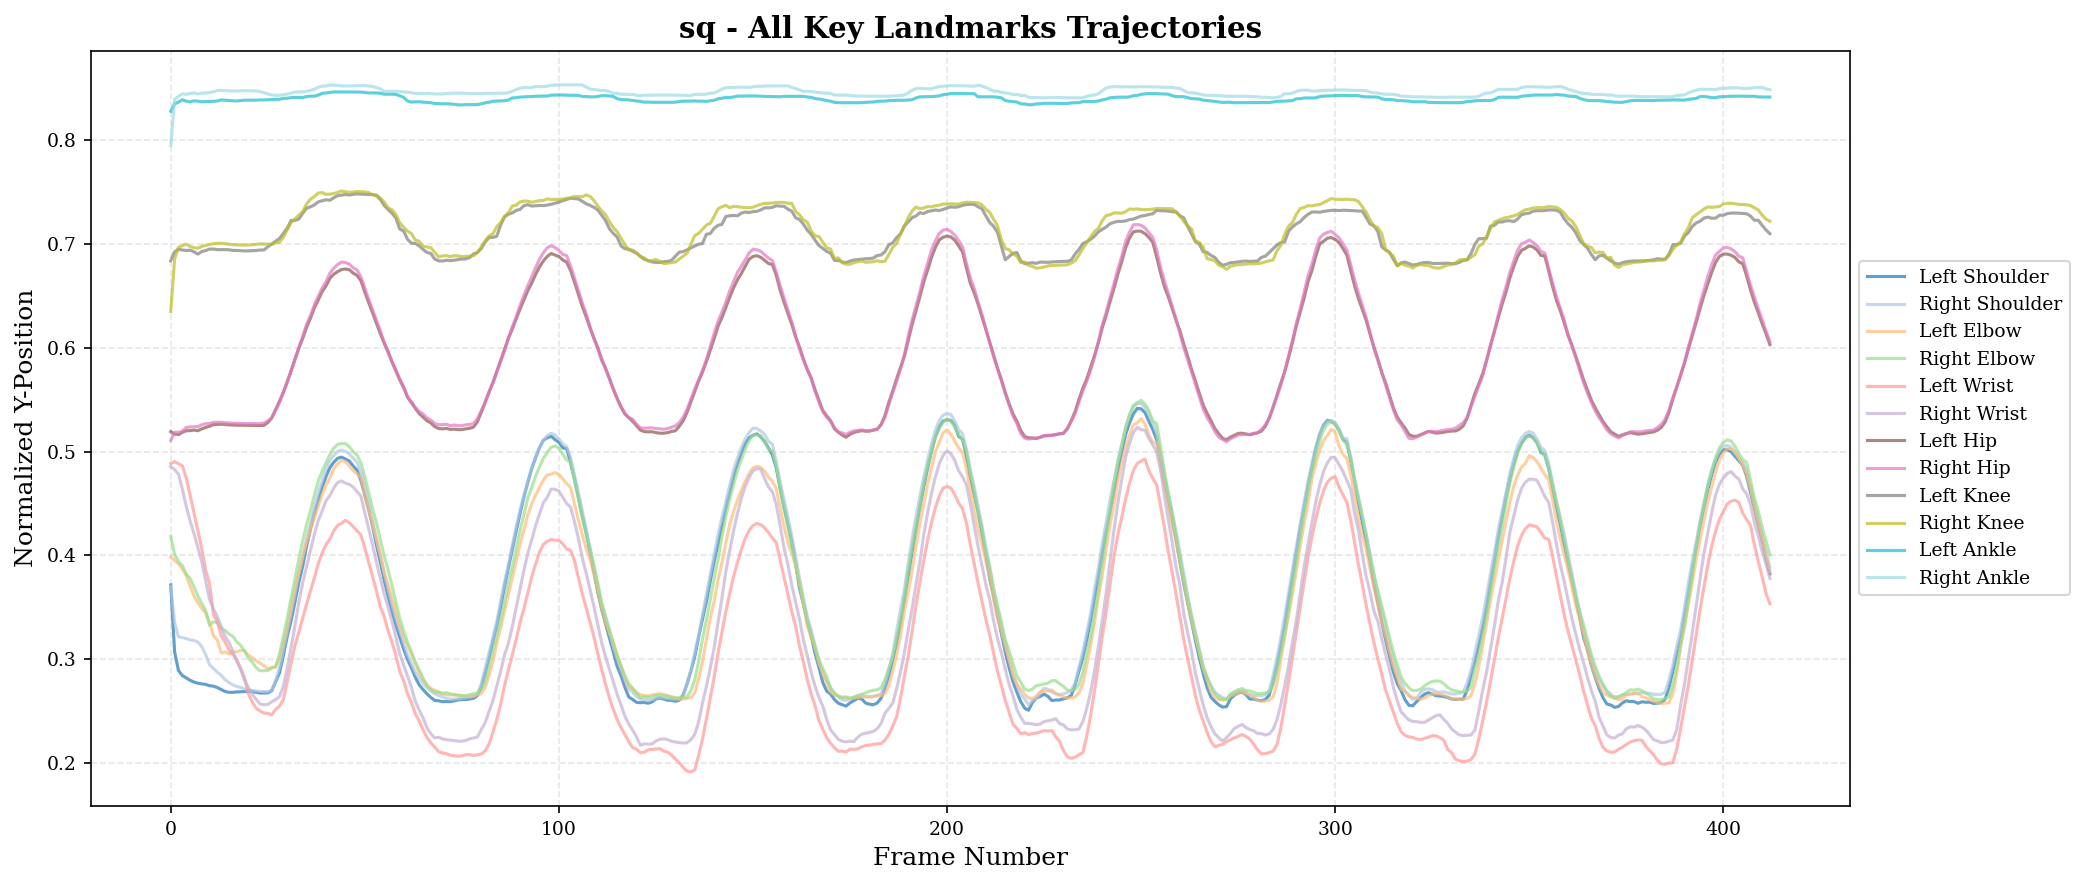

[2/4] Generating all landmarks overlay for lunges...
✓ Saved: paper_visualizations/fig6_lunges_all_landmarks.png


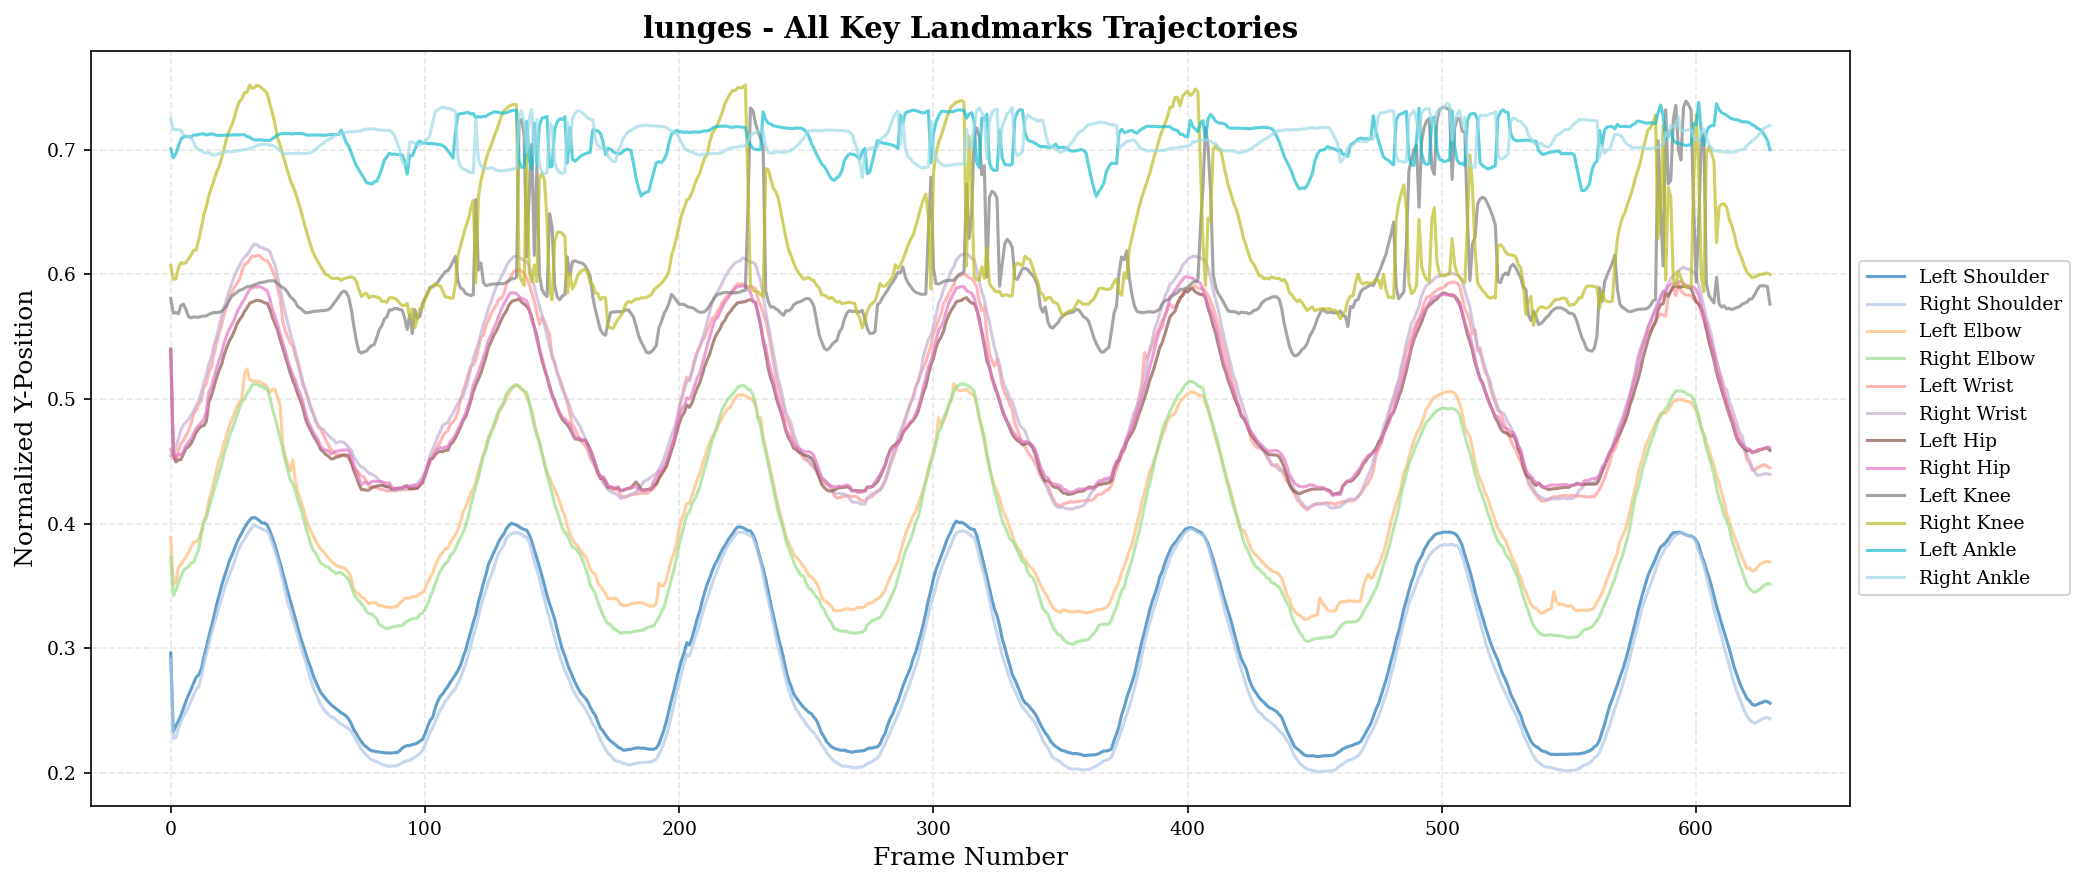

[3/4] Generating all landmarks overlay for pu...
✓ Saved: paper_visualizations/fig6_pu_all_landmarks.png


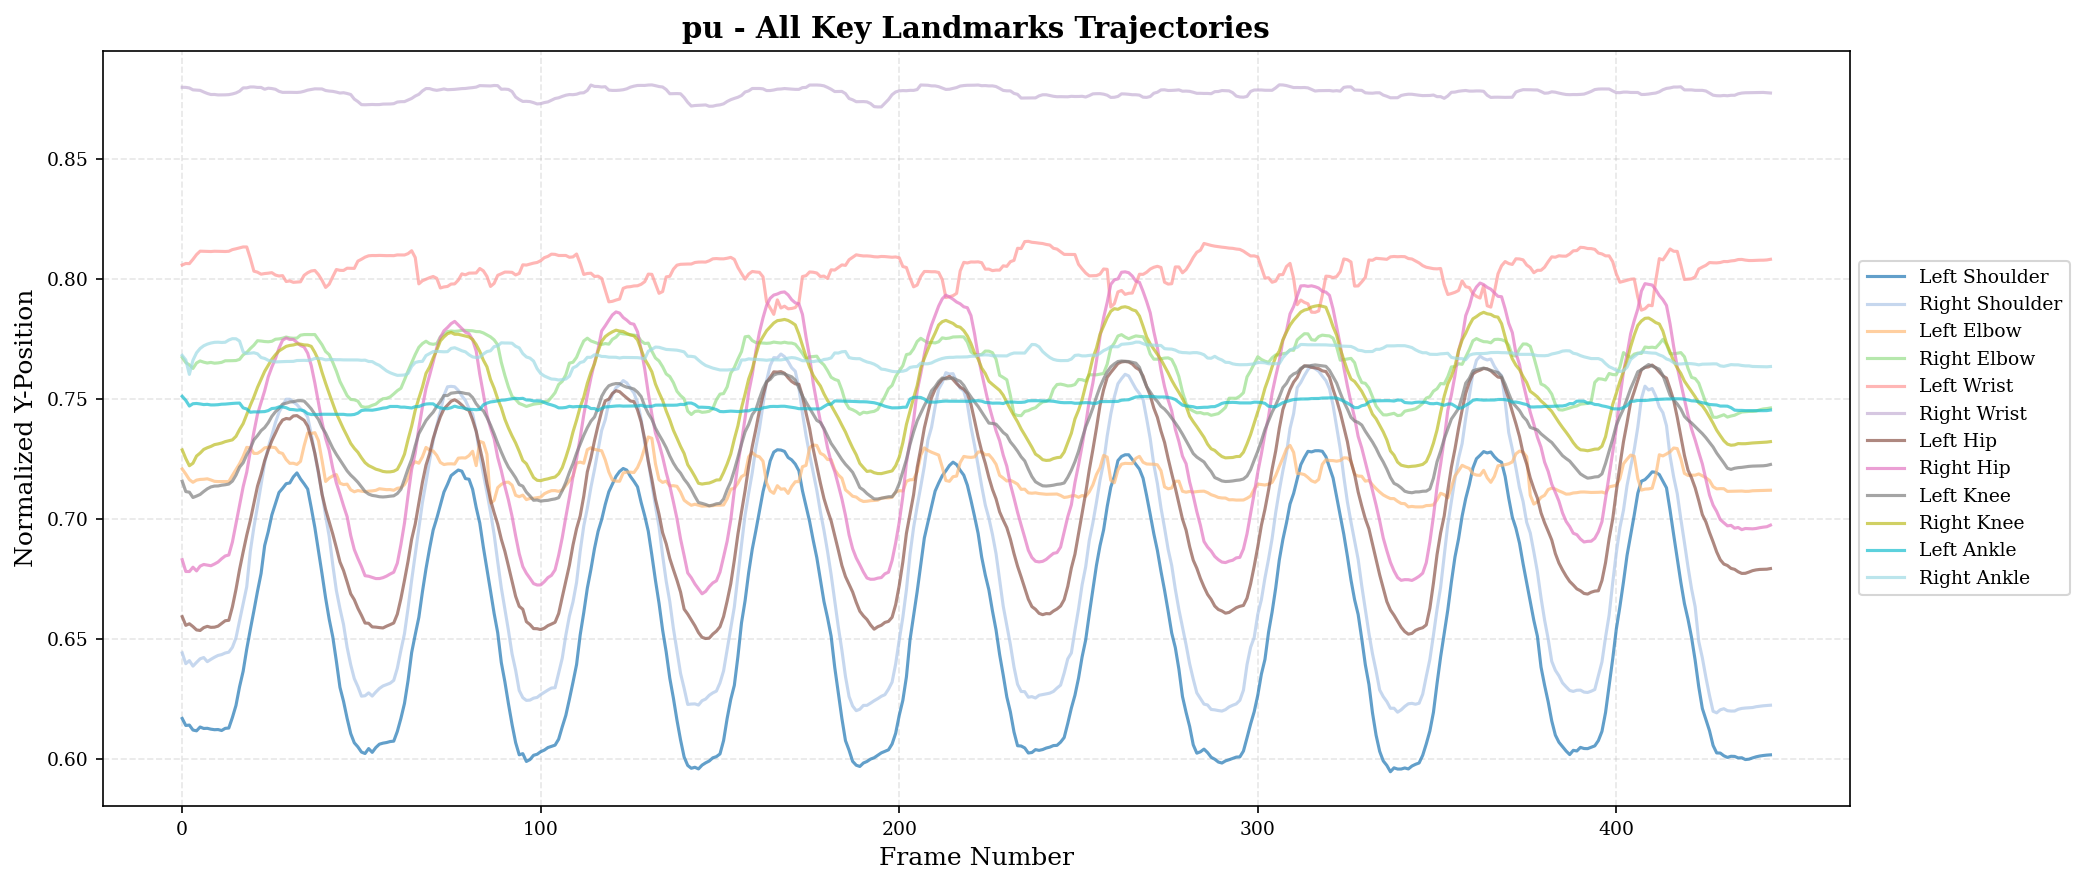

[4/4] Generating all landmarks overlay for shp...
✓ Saved: paper_visualizations/fig6_shp_all_landmarks.png


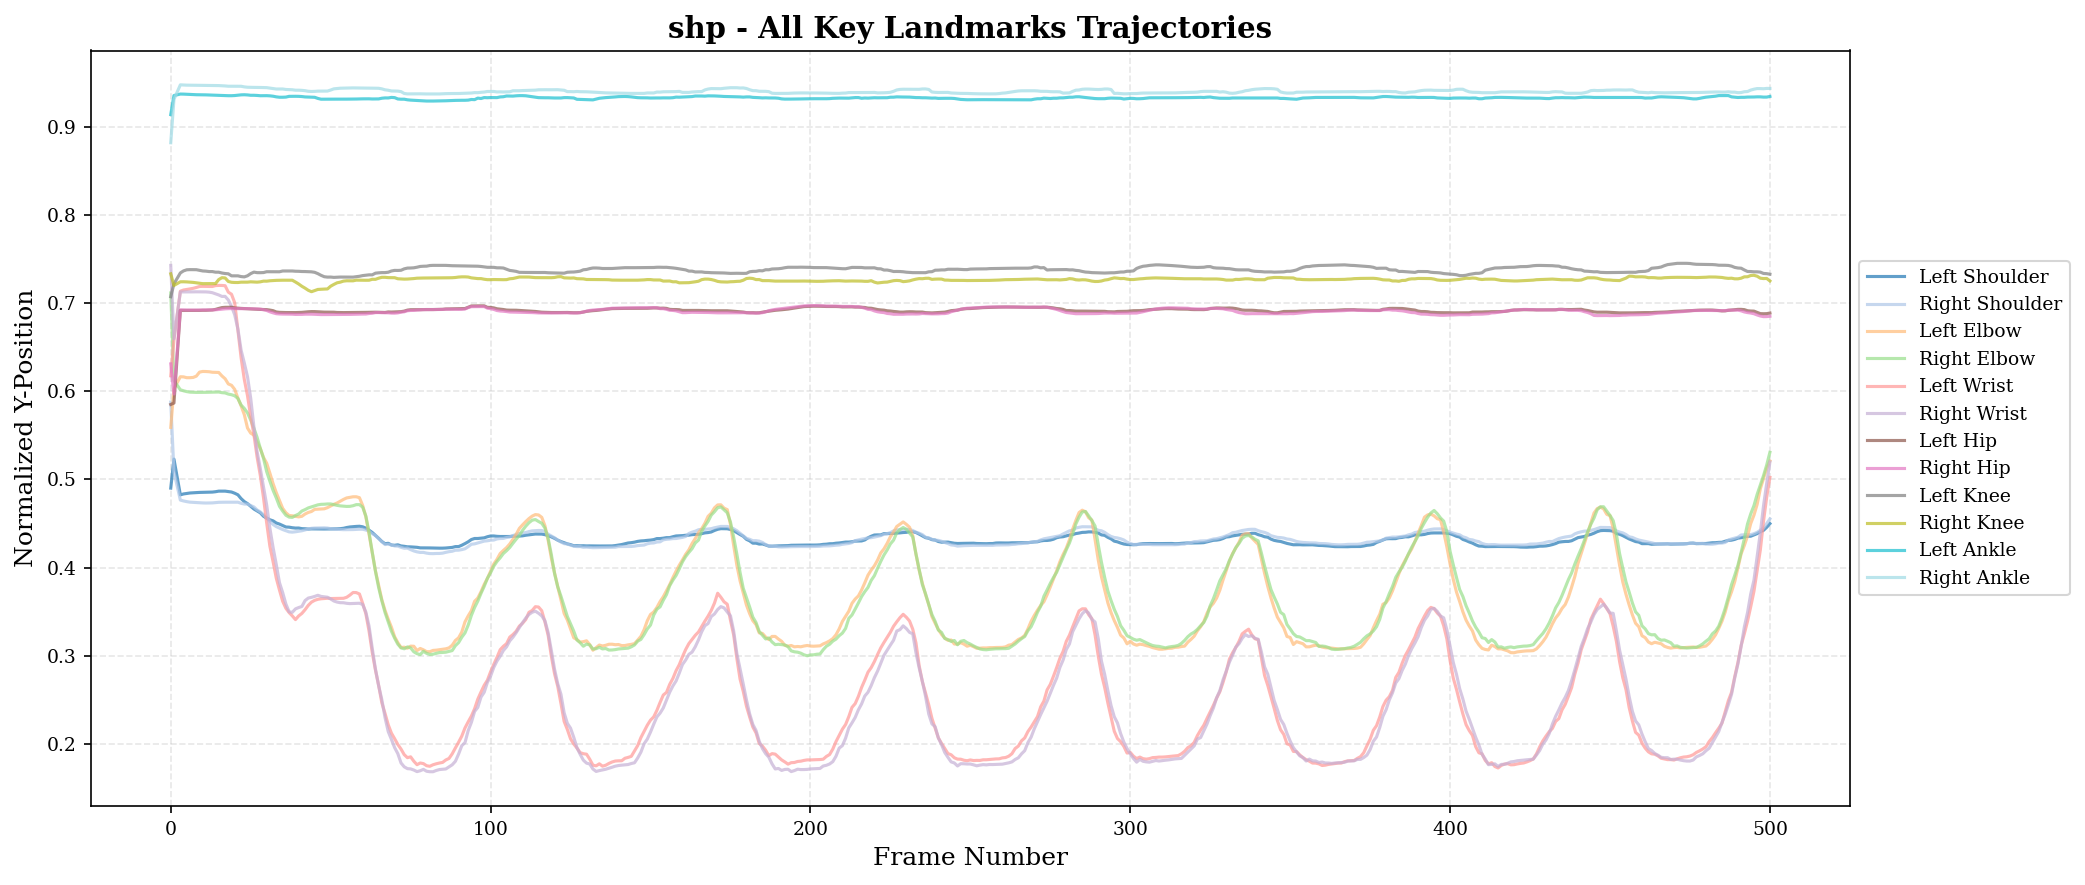

In [9]:
def plot_all_landmarks_overlay(data_dict, exercise_name, filename=None):
    """Overlay all 12 key landmarks for an exercise"""
    if exercise_name not in data_dict or not data_dict[exercise_name]:
        return
    
    df = data_dict[exercise_name][0]['data']
    
    key_landmarks = ['left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
                    'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
                    'left_knee', 'right_knee', 'left_ankle', 'right_ankle']
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    colors_palette = plt.cm.tab20(np.linspace(0, 1, len(key_landmarks)))
    
    for idx, landmark_name in enumerate(key_landmarks):
        positions = extract_landmark_positions(df, landmark_name)
        ax.plot(positions['frame'], positions['y'], 
               color=colors_palette[idx], 
               linewidth=1.5, 
               label=landmark_name.replace('_', ' ').title(),
               alpha=0.7)
    
    ax.set_title(f'{exercise_name} - All Key Landmarks Trajectories', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Frame Number', fontsize=12)
    ax.set_ylabel('Normalized Y-Position', fontsize=12)
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    
    if filename is None:
        filename = f'{exercise_name.lower()}_all_landmarks.png'
    
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()
    plt.close()

for idx, exercise in enumerate(CONFIG['exercises']):
    print(f"[{idx+1}/{len(CONFIG['exercises'])}] Generating all landmarks overlay for {exercise}...")
    plot_all_landmarks_overlay(
        sample_data_side,
        exercise_name=exercise,
        filename=f'fig6_{exercise.lower()}_all_landmarks.png'
    )

## VISUALIZATION - ANGLE RANGE COMPARISON

✓ Saved: paper_visualizations/fig7_angle_ranges.png


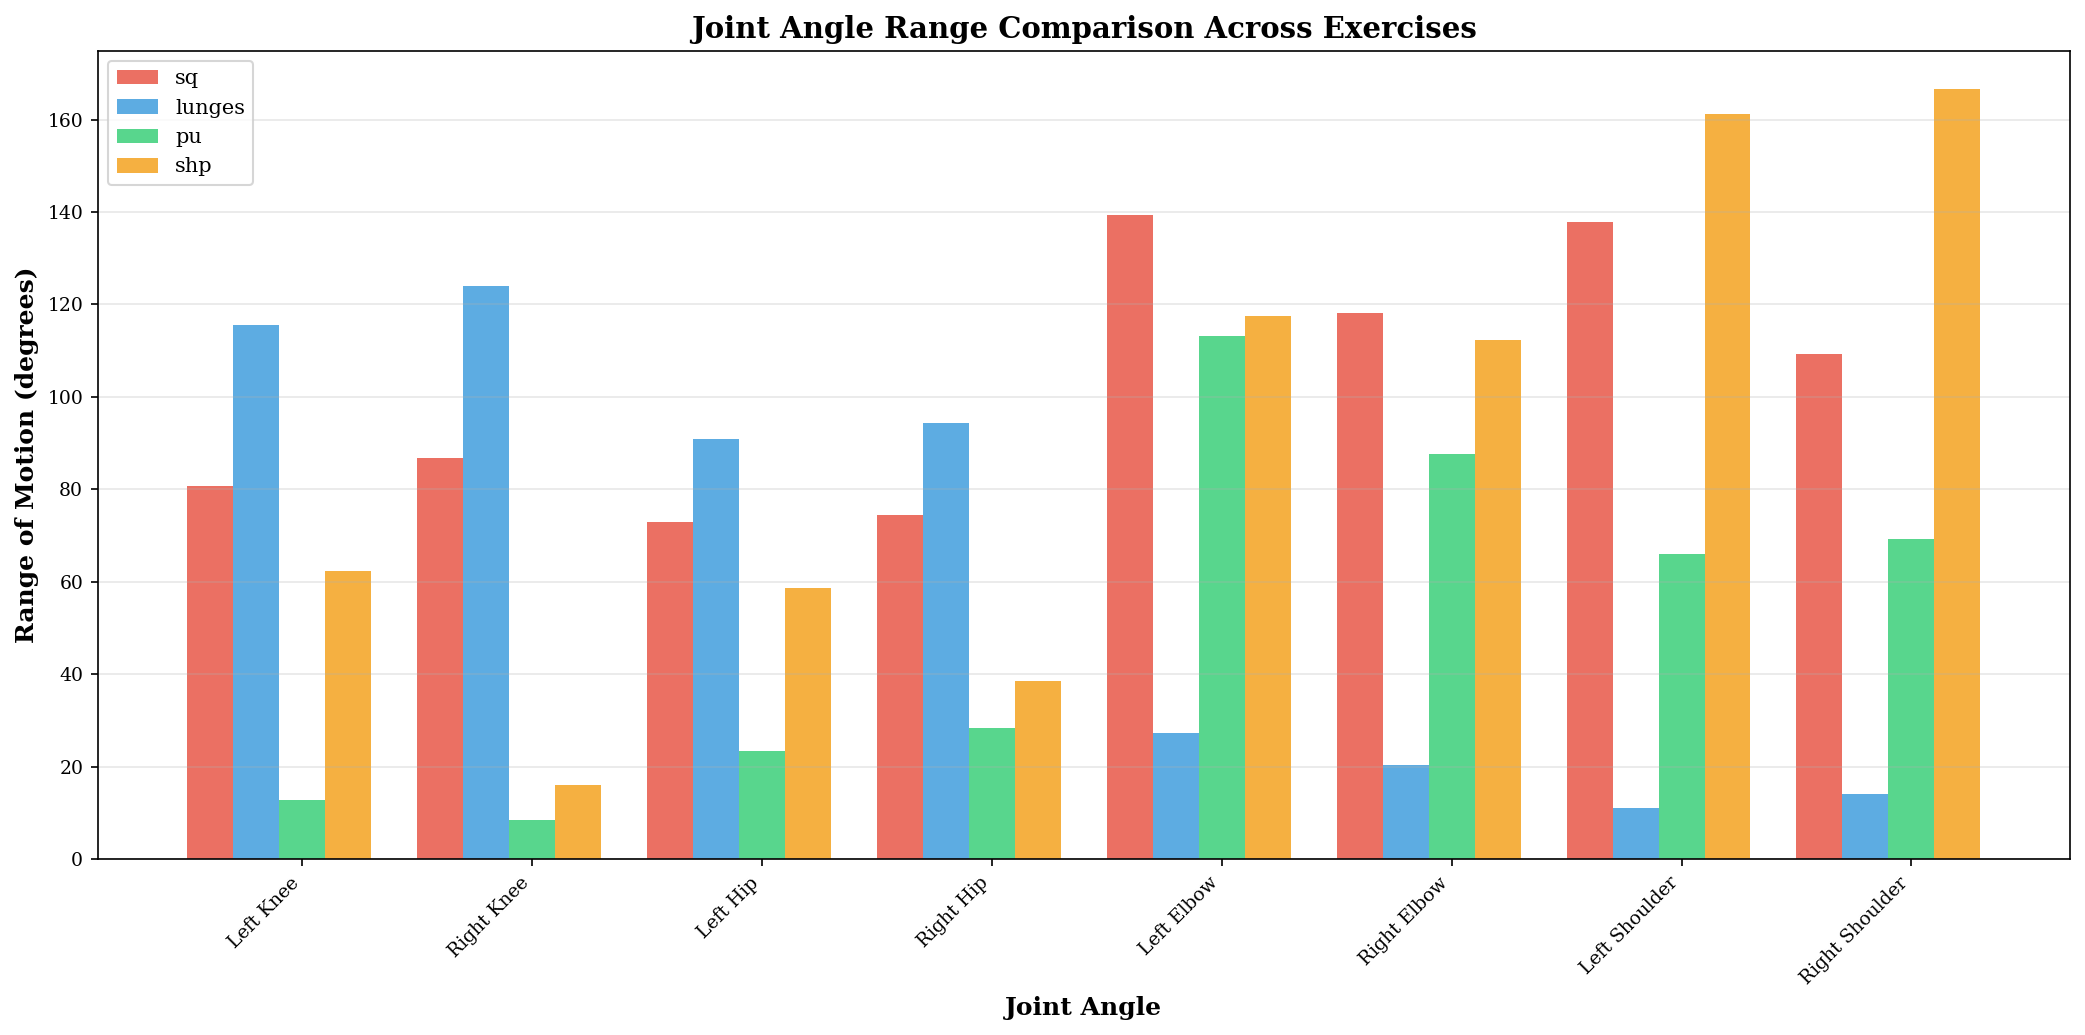

In [10]:
def plot_angle_range_comparison(data_dict, filename='fig7_angle_ranges.png'):
    """Bar chart comparing angle ranges across exercises"""
    angle_names = ['left_knee', 'right_knee', 'left_hip', 'right_hip',
                  'left_elbow', 'right_elbow', 'left_shoulder', 'right_shoulder']
    
    angle_ranges = {exercise: [] for exercise in data_dict.keys()}
    
    for exercise, samples in data_dict.items():
        if samples:
            df = samples[0]['data']
            angles_df = extract_angles_timeseries(df)
            
            for angle_name in angle_names:
                angle_data = angles_df[angle_name].dropna()
                if len(angle_data) > 0:
                    angle_range = angle_data.max() - angle_data.min()
                    angle_ranges[exercise].append(angle_range)
                else:
                    angle_ranges[exercise].append(0)
    
    # Create grouped bar chart
    x = np.arange(len(angle_names))
    width = 0.8 / len(angle_ranges)
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    for idx, (exercise, ranges) in enumerate(angle_ranges.items()):
        offset = width * idx - (width * len(angle_ranges) / 2)
        ax.bar(x + offset, ranges, width, 
               label=exercise, 
               color=EXERCISE_COLORS[exercise],
               alpha=0.8)
    
    ax.set_xlabel('Joint Angle', fontsize=12, fontweight='bold')
    ax.set_ylabel('Range of Motion (degrees)', fontsize=12, fontweight='bold')
    ax.set_title('Joint Angle Range Comparison Across Exercises', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([name.replace('_', ' ').title() for name in angle_names], 
                       rotation=45, ha='right')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()
    plt.close()

plot_angle_range_comparison(sample_data_side)

## VISUALIZATION - VELOCITY PROFILES

✓ Saved: paper_visualizations/fig8_velocity_profiles.png


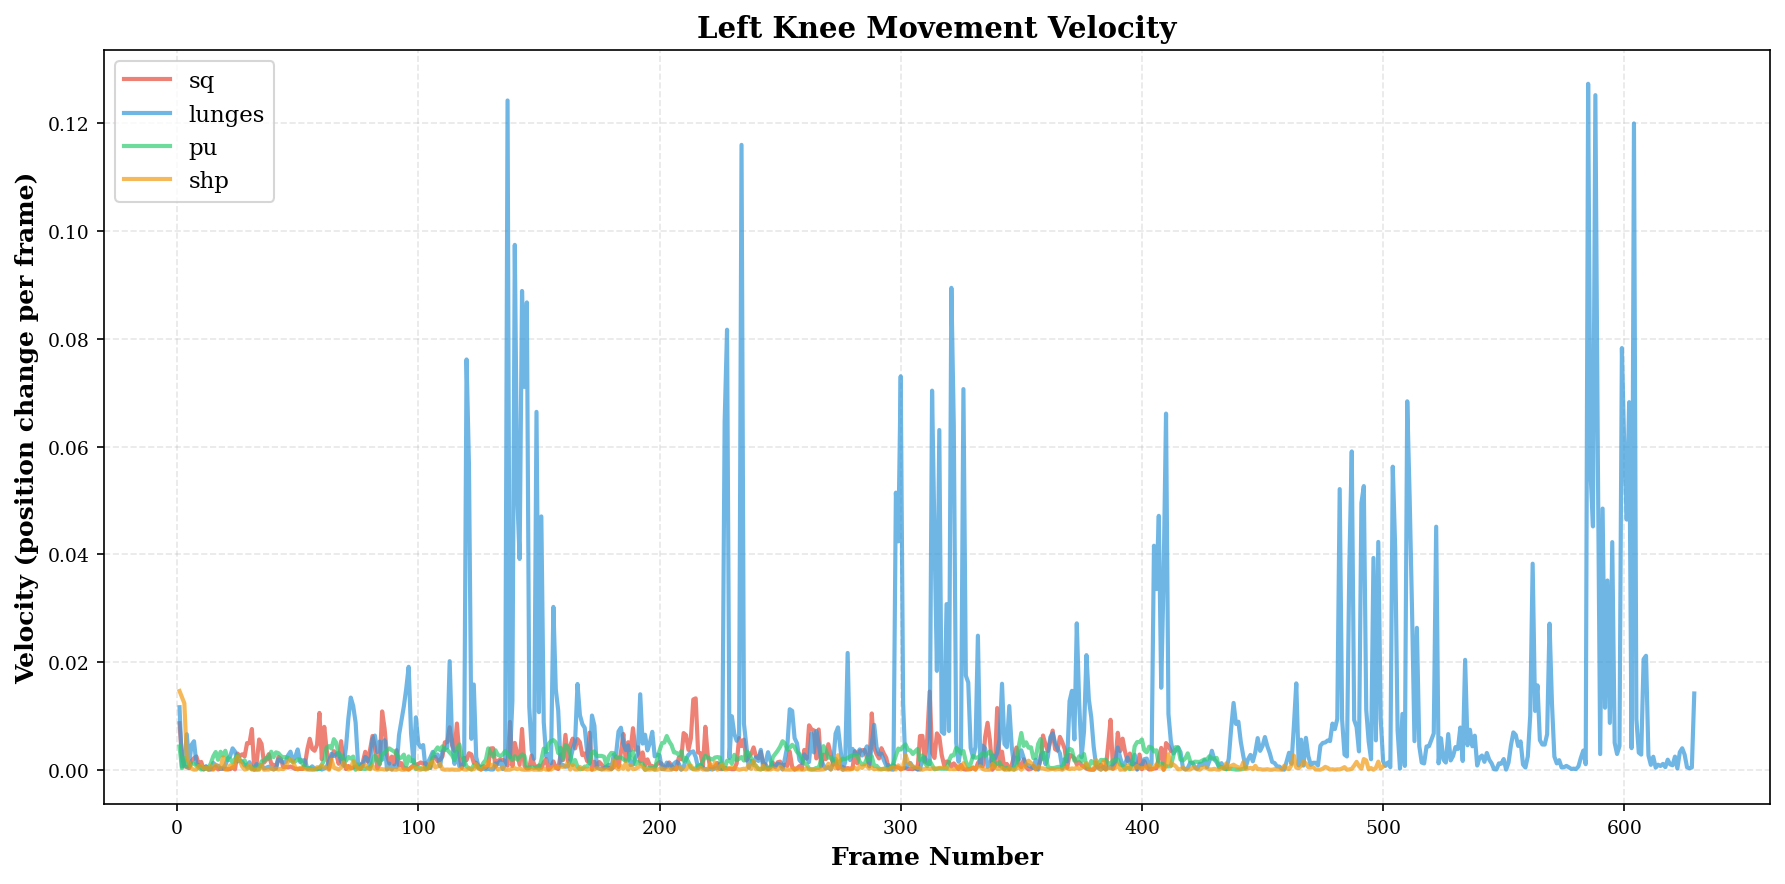

In [11]:
def plot_velocity_profiles(data_dict, landmark_name='left_knee', 
                          filename='fig8_velocity_profiles.png'):
    """Plot velocity (rate of change) for a landmark"""
    lm_idx = LANDMARKS[landmark_name]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for exercise, samples in data_dict.items():
        if samples:
            df = samples[0]['data']
            y_data = df[f'landmark_{lm_idx}_y'].values
            
            # Calculate velocity (first derivative)
            velocity = np.abs(np.diff(y_data))
            frames = df['frame'].values[1:]
            
            ax.plot(frames, velocity, 
                   color=EXERCISE_COLORS[exercise], 
                   linewidth=2, 
                   label=exercise, 
                   alpha=0.7)
    
    ax.set_xlabel('Frame Number', fontsize=12, fontweight='bold')
    ax.set_ylabel('Velocity (position change per frame)', fontsize=12, fontweight='bold')
    ax.set_title(f'{landmark_name.replace("_", " ").title()} Movement Velocity', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()
    plt.close()

plot_velocity_profiles(sample_data_side, landmark_name='left_knee')

## VISUALIZATION - SYMMETRY ANALYSIS

[1/4] Analyzing symmetry for sq...
✓ Saved: paper_visualizations/fig9_sq_symmetry.png


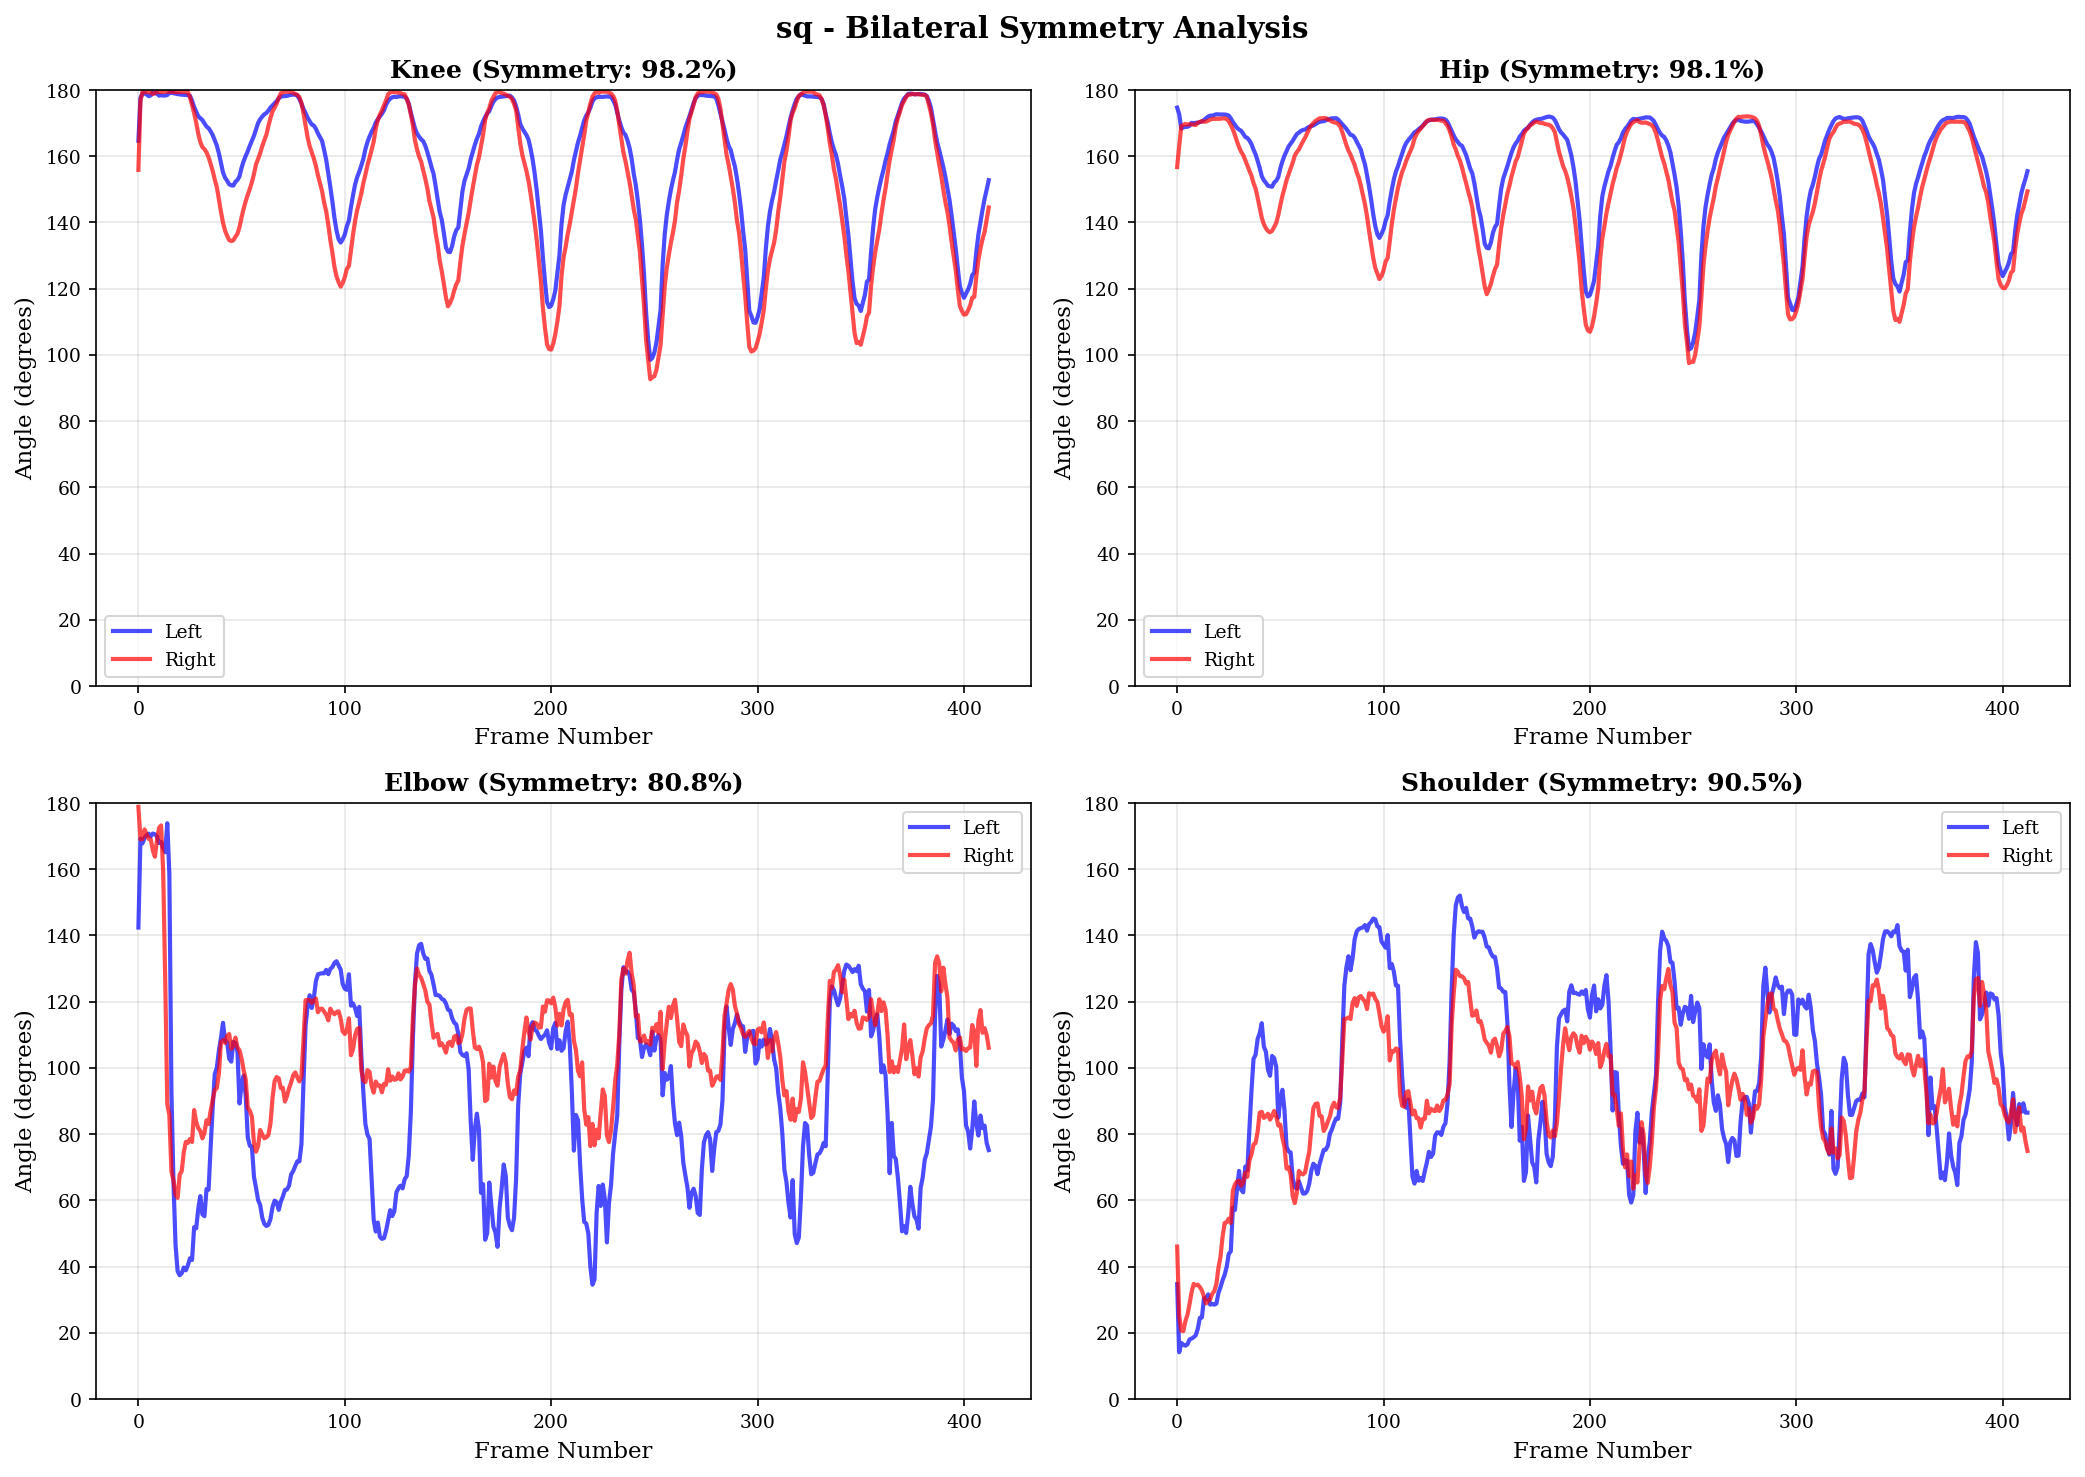

[2/4] Analyzing symmetry for lunges...
✓ Saved: paper_visualizations/fig9_lunges_symmetry.png


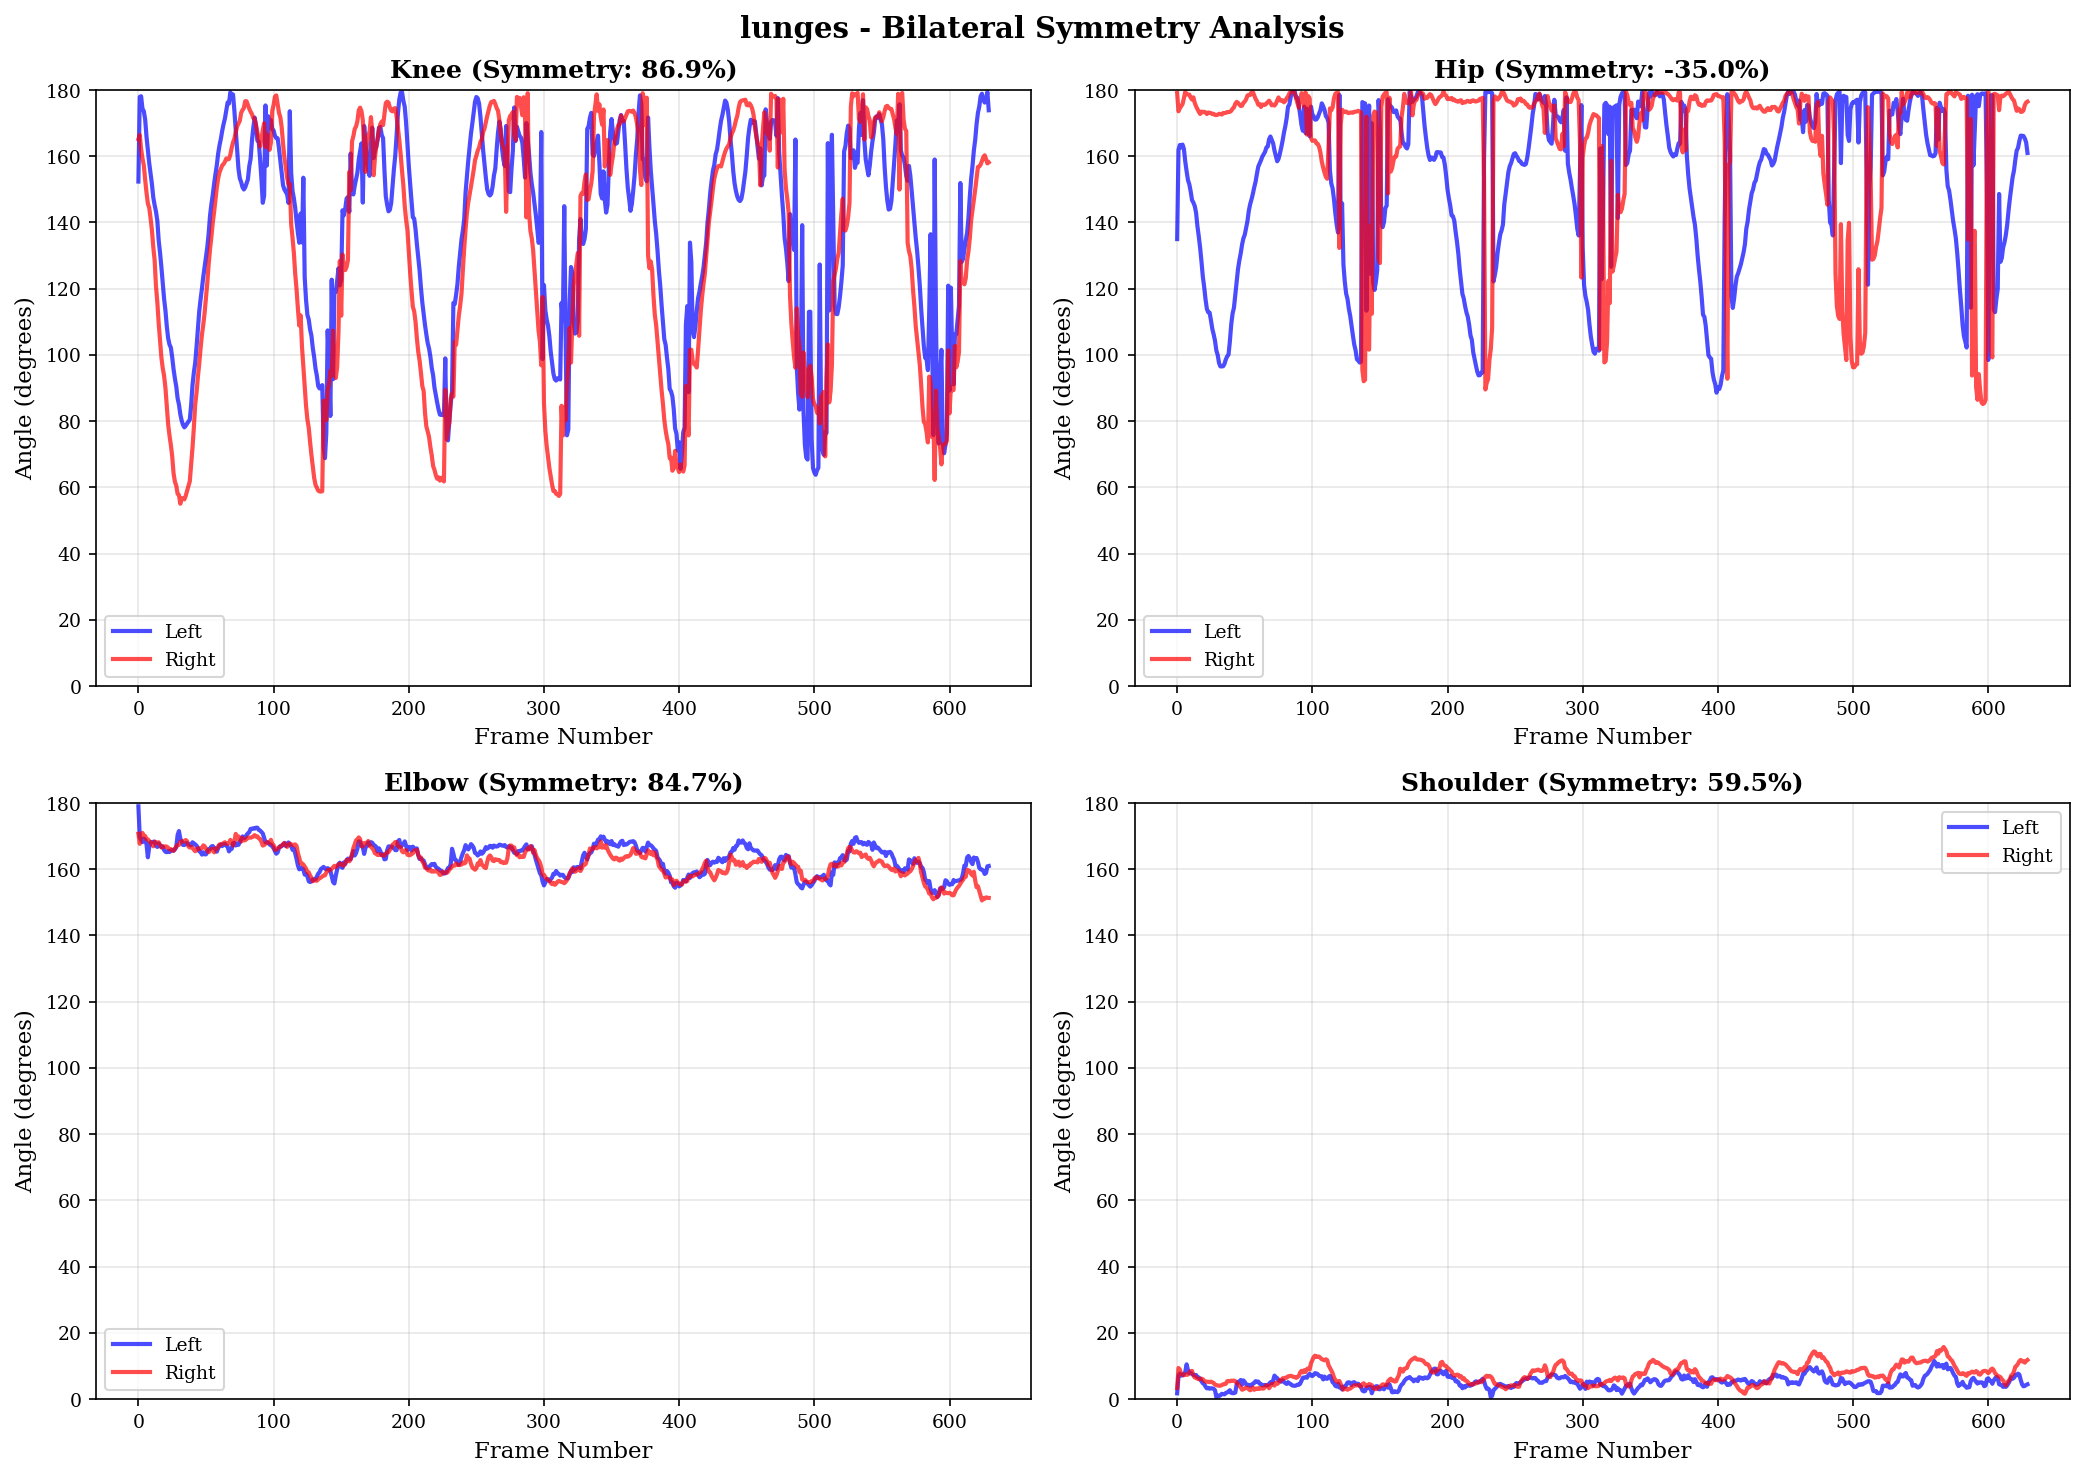

[3/4] Analyzing symmetry for pu...
✓ Saved: paper_visualizations/fig9_pu_symmetry.png


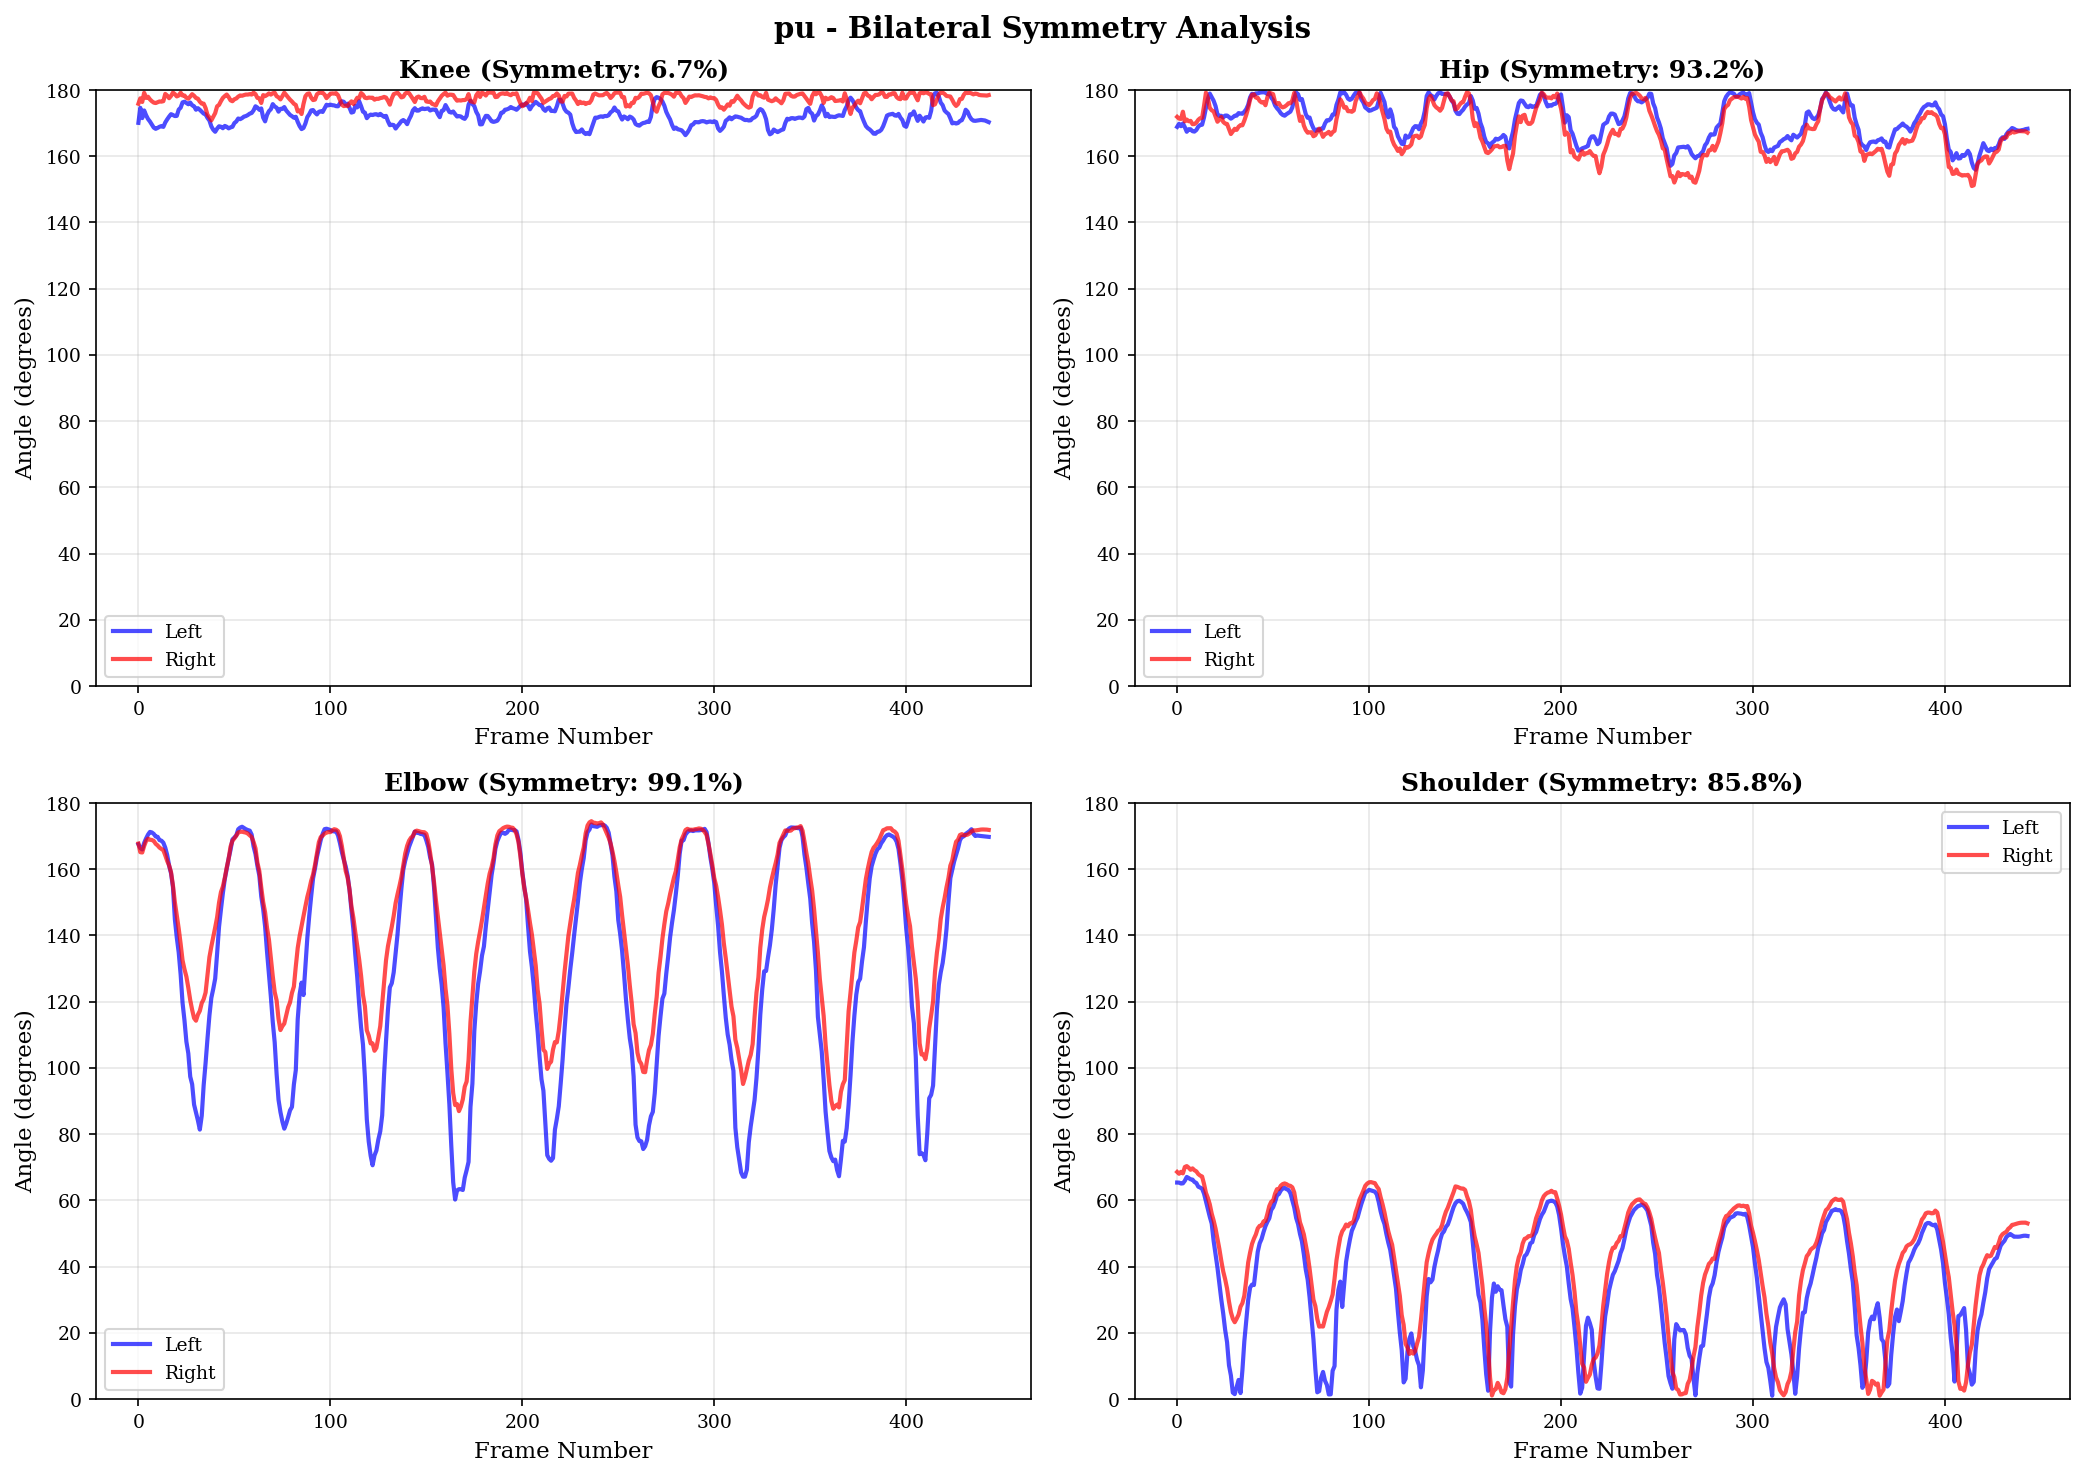

[4/4] Analyzing symmetry for shp...
✓ Saved: paper_visualizations/fig9_shp_symmetry.png


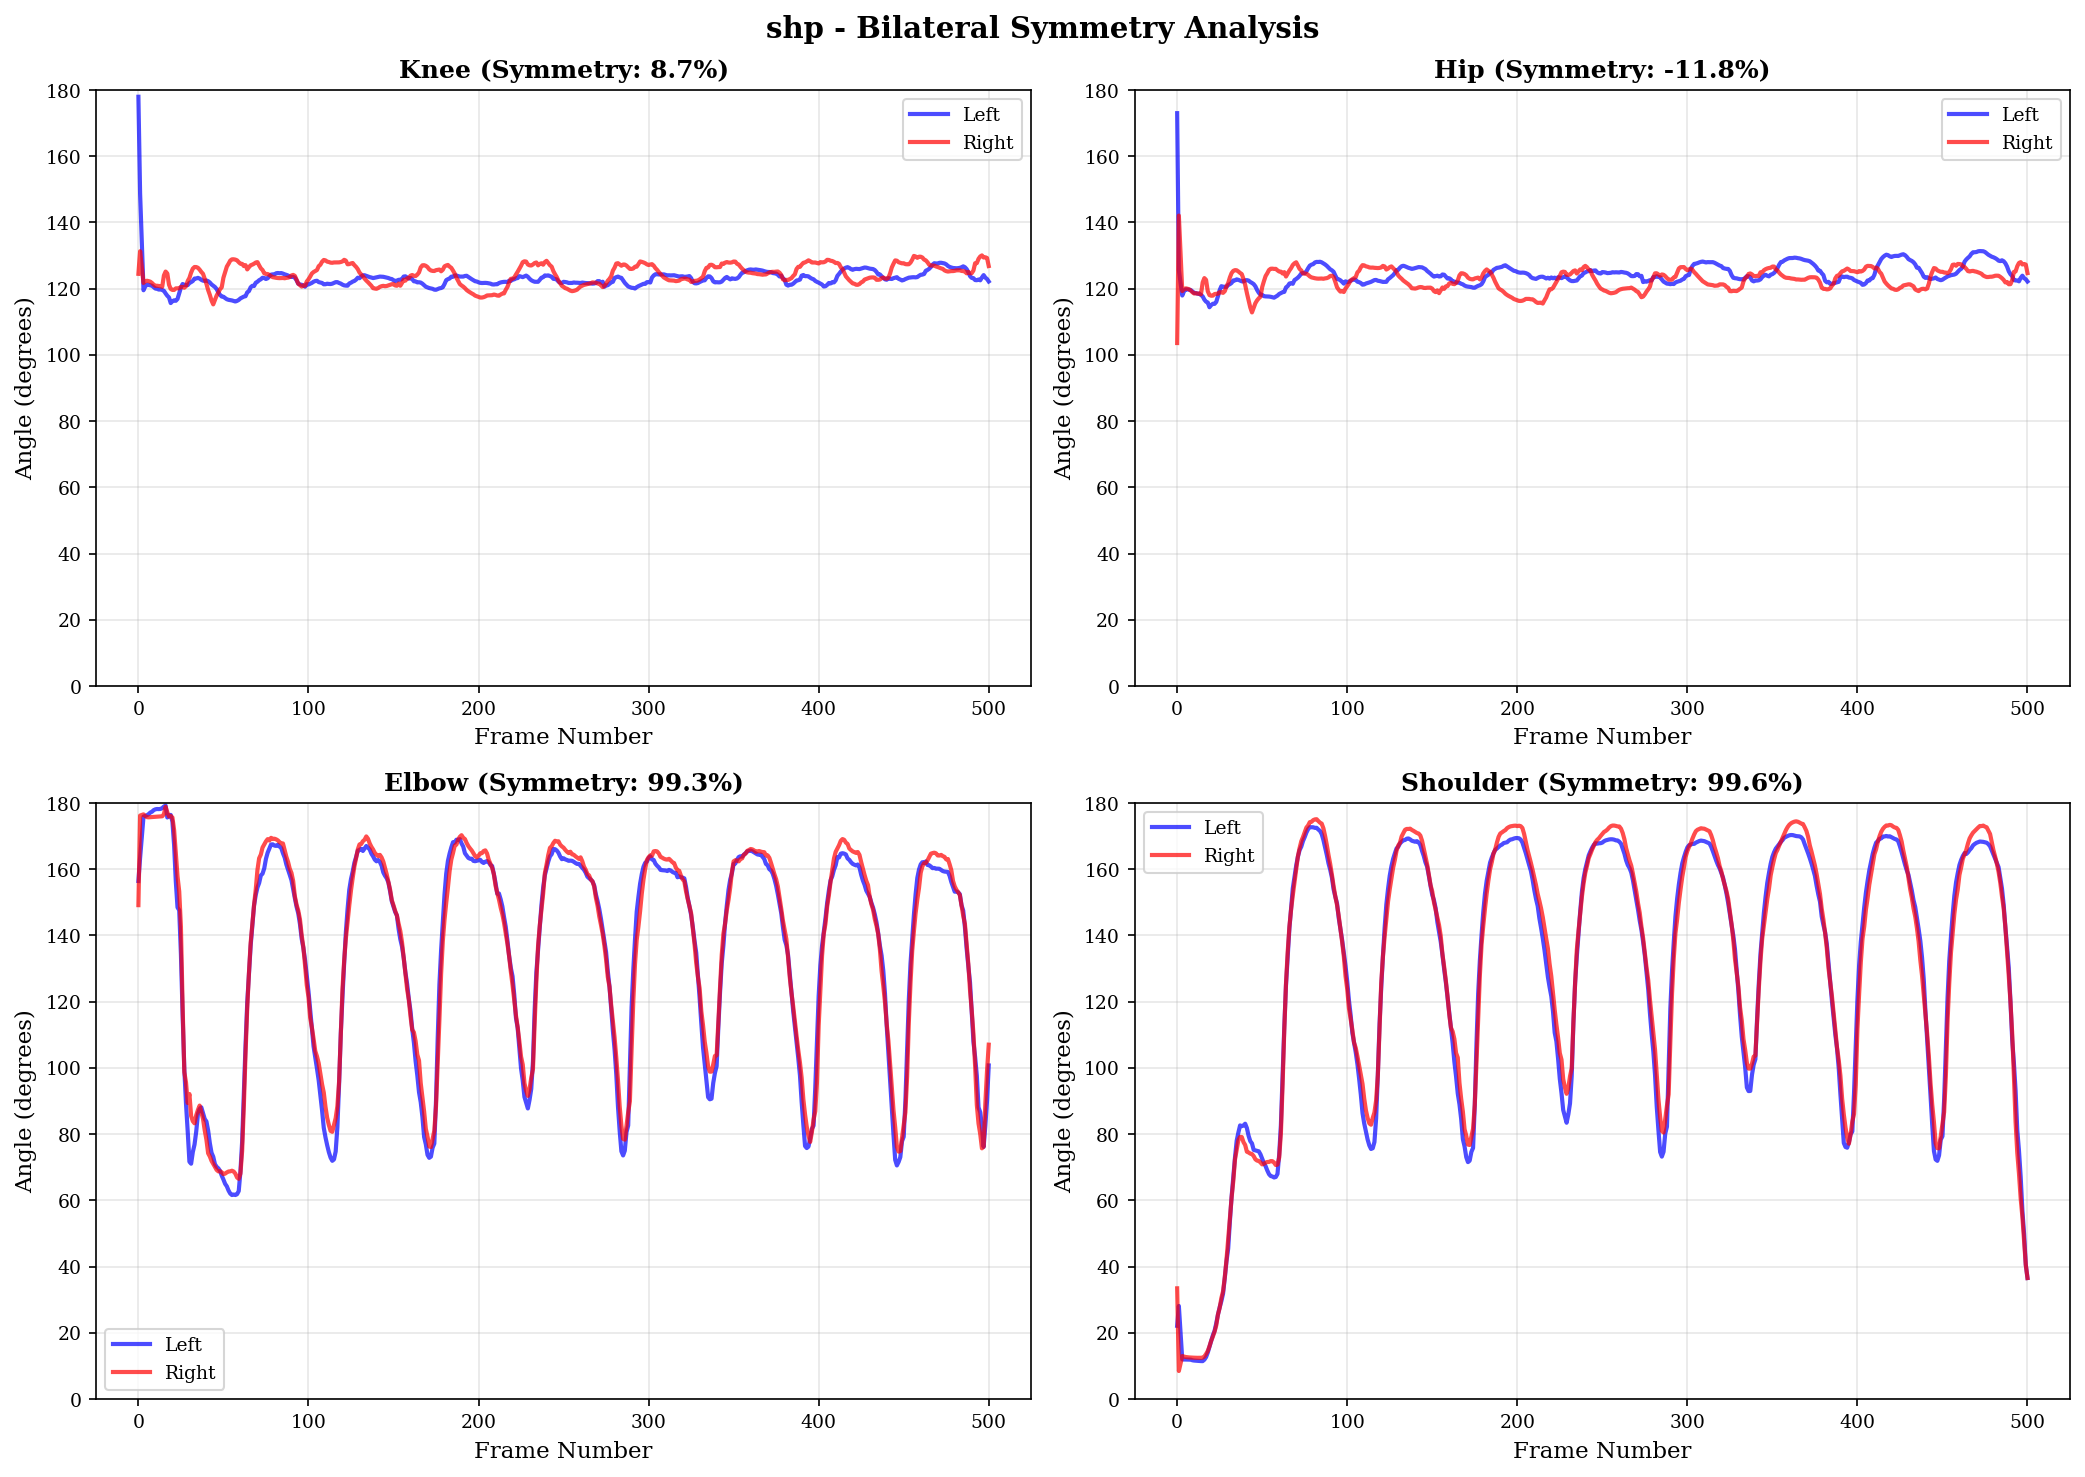

In [12]:
def plot_symmetry_analysis(data_dict, exercise_name, 
                          filename=None):
    """Compare left vs right side movements"""
    if exercise_name not in data_dict or not data_dict[exercise_name]:
        return
    
    df = data_dict[exercise_name][0]['data']
    angles_df = extract_angles_timeseries(df)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    pairs = [
        ('left_knee', 'right_knee'),
        ('left_hip', 'right_hip'),
        ('left_elbow', 'right_elbow'),
        ('left_shoulder', 'right_shoulder')
    ]
    
    for idx, (left_angle, right_angle) in enumerate(pairs):
        ax = axes[idx // 2, idx % 2]
        
        ax.plot(angles_df['frame'], angles_df[left_angle], 
               color='blue', linewidth=2, label='Left', alpha=0.7)
        ax.plot(angles_df['frame'], angles_df[right_angle], 
               color='red', linewidth=2, label='Right', alpha=0.7)
        
        # Calculate symmetry score (correlation)
        left_data = angles_df[left_angle].dropna()
        right_data = angles_df[right_angle].dropna()
        min_len = min(len(left_data), len(right_data))
        if min_len > 0:
            correlation = np.corrcoef(left_data[:min_len], right_data[:min_len])[0, 1]
            symmetry_score = correlation * 100
        else:
            symmetry_score = 0
        
        ax.set_title(f'{left_angle.replace("left_", "").replace("_", " ").title()} '
                    f'(Symmetry: {symmetry_score:.1f}%)', 
                    fontweight='bold')
        ax.set_xlabel('Frame Number')
        ax.set_ylabel('Angle (degrees)')
        ax.set_ylim(0, 180)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f'{exercise_name} - Bilateral Symmetry Analysis', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if filename is None:
        filename = f'{exercise_name.lower()}_symmetry.png'
    
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()
    plt.close()

for idx, exercise in enumerate(CONFIG['exercises']):
    print(f"[{idx+1}/{len(CONFIG['exercises'])}] Analyzing symmetry for {exercise}...")
    plot_symmetry_analysis(
        sample_data_side,
        exercise_name=exercise,
        filename=f'fig9_{exercise.lower()}_symmetry.png'
    )

# Feature Engineering

In [13]:
# Auto-detect exercises from folder structure
detected_exercises = detect_exercises(CONFIG['data_dir'], CONFIG['views'])

if detected_exercises:
    exercises = detected_exercises
    print(f"✓ Auto-detected exercises: {exercises}")
else:
    # Fallback to default names
    exercises = ['sq', 'lunges', 'pu', 'shp']
    print(f"Using default exercise names: {exercises}")

all_videos = get_all_videos(CONFIG['data_dir'], CONFIG['views'], exercises)

if len(all_videos) == 0:
    print("\n ERROR: No videos loaded!")
    print(f"   Check that {CONFIG['data_dir']}/{CONFIG['views']}/ exists")
    print(f"   and contains exercise folders with CSV files.")
    raise ValueError("No training data found. Please run keypoint extraction first.")

print(f"\n✓ Total videos loaded: {len(all_videos)}")
print("\nVideos per exercise:")
for exercise in exercises:
    count = sum(1 for v in all_videos if v['exercise'] == exercise)
    print(f"  {exercise}: {count} videos")
print()

# Verify we have data to process
if 'all_videos' not in locals() or len(all_videos) == 0:
    print("\n ERROR: No videos available for feature extraction!")
    print("   Please run Section 2 (Data Loading) first.")
    raise ValueError("all_videos is not defined or empty")

# Extract features from all videos
print("Extracting features from all videos...")
all_features = []

for idx, video in enumerate(all_videos):
    try:
        features = extract_all_features(video)
        all_features.append(features)
        
        if (idx + 1) % 10 == 0:
            print(f"  Processed {idx + 1}/{len(all_videos)} videos...")
    except Exception as e:
        print(f"  Error processing {video['filename']}: {e}")

# Verify we extracted features
if len(all_features) == 0:
    print("\n ERROR: No features extracted!")
    raise ValueError("Feature extraction failed for all videos")

# Convert to DataFrame
features_df = pd.DataFrame(all_features)

# Separate features and labels
X_columns = [col for col in features_df.columns 
             if col not in ['exercise', 'filename', 'n_frames']]
X = features_df[X_columns].values
y = features_df['exercise'].values
filenames = features_df['filename'].values

# Handle any NaN values
X = np.nan_to_num(X, nan=0.0)

print(f"\n✓ Feature extraction complete!")
print(f"  Total samples: {len(X)}")
print(f"  Total features: {len(X_columns)}")

✓ Auto-detected exercises: ['lunges', 'pu', 'shp', 'sq']

✓ Total videos loaded: 390

Videos per exercise:
  lunges: 98 videos
  pu: 97 videos
  shp: 98 videos
  sq: 97 videos

Extracting features from all videos...
  Processed 10/390 videos...
  Processed 20/390 videos...
  Processed 30/390 videos...
  Processed 40/390 videos...
  Processed 50/390 videos...
  Processed 60/390 videos...
  Processed 70/390 videos...
  Processed 80/390 videos...
  Processed 90/390 videos...
  Processed 100/390 videos...
  Processed 110/390 videos...
  Processed 120/390 videos...
  Processed 130/390 videos...
  Processed 140/390 videos...
  Processed 150/390 videos...
  Processed 160/390 videos...
  Processed 170/390 videos...
  Processed 180/390 videos...
  Processed 190/390 videos...
  Processed 200/390 videos...
  Processed 210/390 videos...
  Processed 220/390 videos...
  Processed 230/390 videos...
  Processed 240/390 videos...
  Processed 250/390 videos...
  Processed 260/390 videos...
  Processed 2

## DATASET PREPARATION

In [14]:

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_}")
print(f"Encoded as: {np.unique(y_encoded)}")

# Split data: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test, files_temp, files_test = train_test_split(
    X, y_encoded, filenames, 
    test_size=CONFIG['test_size'], 
    random_state=CONFIG['random_state'],
    stratify=y_encoded
)

X_train, X_val, y_train, y_val, files_train, files_val = train_test_split(
    X_temp, y_temp, files_temp,
    test_size=CONFIG['val_size']/(1-CONFIG['test_size']),
    random_state=CONFIG['random_state'],
    stratify=y_temp
)

print(f"\n✓ Data split:")
print(f"  Training: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features normalized using StandardScaler")
print()

Classes: ['lunges' 'pu' 'shp' 'sq']
Encoded as: [0 1 2 3]

✓ Data split:
  Training: 272 samples (69.7%)
  Validation: 59 samples (15.1%)
  Test: 59 samples (15.1%)

✓ Features normalized using StandardScaler



# MODEL TRAINING & EVALUATION

In [15]:
# Dictionary to store all models and results
models = {}
results = {}

## MODEL 1 - Random Forest

In [16]:

print("\n" + "="*80)
print("MODEL 1: Random Forest Classifier")
print("="*80)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# Validation performance
y_val_pred_rf = rf_model.predict(X_val_scaled)
val_acc_rf = accuracy_score(y_val, y_val_pred_rf)

# Test performance
y_test_pred_rf = rf_model.predict(X_test_scaled)
test_acc_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"\n✓ Validation Accuracy: {val_acc_rf*100:.2f}%")
print(f"✓ Test Accuracy: {test_acc_rf*100:.2f}%")

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, 
                               cv=CONFIG['n_cv_folds'], scoring='accuracy')
print(f"\n{CONFIG['n_cv_folds']}-Fold CV Accuracy: {cv_scores_rf.mean()*100:.2f}% (+/- {cv_scores_rf.std()*100:.2f}%)")

models['random_forest'] = rf_model
results['random_forest'] = {
    'val_accuracy': val_acc_rf,
    'test_accuracy': test_acc_rf,
    'cv_scores': cv_scores_rf,
    'y_test_pred': y_test_pred_rf,
    'y_val_pred': y_val_pred_rf
}

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
for idx, row in feature_importance.head(15).iterrows():
    print(f"  {row['feature']:<40} {row['importance']:.4f}")



MODEL 1: Random Forest Classifier
Training Random Forest...

✓ Validation Accuracy: 100.00%
✓ Test Accuracy: 100.00%

5-Fold CV Accuracy: 100.00% (+/- 0.00%)

Top 15 Most Important Features:
  right_shoulder_y_std                     0.0371
  left_shoulder_y_std                      0.0344
  left_elbow_y_mean                        0.0338
  nose_y_std                               0.0336
  hip_velocity_mean                        0.0306
  nose_y_mean                              0.0297
  right_heel_y_std                         0.0269
  left_wrist_y_mean                        0.0269
  right_shoulder_y_mean                    0.0265
  right_shoulder_y_min                     0.0259
  right_knee_y_std                         0.0255
  nose_y_max                               0.0250
  left_shoulder_y_min                      0.0238
  left_shoulder_angle_mean                 0.0237
  left_knee_y_std                          0.0233


## MODEL 2 - Gradient Boosting

In [17]:
gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_SEED
)

print("Training Gradient Boosting...")
gb_model.fit(X_train_scaled, y_train)

y_val_pred_gb = gb_model.predict(X_val_scaled)
val_acc_gb = accuracy_score(y_val, y_val_pred_gb)

y_test_pred_gb = gb_model.predict(X_test_scaled)
test_acc_gb = accuracy_score(y_test, y_test_pred_gb)

print(f"\n✓ Validation Accuracy: {val_acc_gb*100:.2f}%")
print(f"✓ Test Accuracy: {test_acc_gb*100:.2f}%")

cv_scores_gb = cross_val_score(gb_model, X_train_scaled, y_train,
                               cv=CONFIG['n_cv_folds'], scoring='accuracy')
print(f"\n{CONFIG['n_cv_folds']}-Fold CV Accuracy: {cv_scores_gb.mean()*100:.2f}% (+/- {cv_scores_gb.std()*100:.2f}%)")

models['gradient_boosting'] = gb_model
results['gradient_boosting'] = {
    'val_accuracy': val_acc_gb,
    'test_accuracy': test_acc_gb,
    'cv_scores': cv_scores_gb,
    'y_test_pred': y_test_pred_gb,
    'y_val_pred': y_val_pred_gb
}

Training Gradient Boosting...

✓ Validation Accuracy: 100.00%
✓ Test Accuracy: 100.00%

5-Fold CV Accuracy: 97.06% (+/- 1.86%)


## MODEL 3 - SVM

In [18]:
svm_model = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    random_state=RANDOM_SEED
)

print("Training SVM...")
svm_model.fit(X_train_scaled, y_train)

y_val_pred_svm = svm_model.predict(X_val_scaled)
val_acc_svm = accuracy_score(y_val, y_val_pred_svm)

y_test_pred_svm = svm_model.predict(X_test_scaled)
test_acc_svm = accuracy_score(y_test, y_test_pred_svm)

print(f"\n Validation Accuracy: {val_acc_svm*100:.2f}%")
print(f" Test Accuracy: {test_acc_svm*100:.2f}%")

cv_scores_svm = cross_val_score(svm_model, X_train_scaled, y_train,
                                cv=CONFIG['n_cv_folds'], scoring='accuracy')
print(f"\n{CONFIG['n_cv_folds']}-Fold CV Accuracy: {cv_scores_svm.mean()*100:.2f}% (+/- {cv_scores_svm.std()*100:.2f}%)")

models['svm'] = svm_model
results['svm'] = {
    'val_accuracy': val_acc_svm,
    'test_accuracy': test_acc_svm,
    'cv_scores': cv_scores_svm,
    'y_test_pred': y_test_pred_svm,
    'y_val_pred': y_val_pred_svm
}

Training SVM...

 Validation Accuracy: 100.00%
 Test Accuracy: 100.00%

5-Fold CV Accuracy: 100.00% (+/- 0.00%)


# RESULTS VISUALIZATION & ANALYSIS

In [19]:

# Select best model based on test accuracy
best_model_name = max(results, key=lambda k: results[k]['test_accuracy'])
best_model = models[best_model_name]
best_results = results[best_model_name]

print(f"\n Best Model: {best_model_name.upper()}")
print(f"   Test Accuracy: {best_results['test_accuracy']*100:.2f}%")
print()

# Detailed classification report for best model
print("Detailed Classification Report (Test Set):")
print("="*80)
report = classification_report(
    y_test, 
    best_results['y_test_pred'],
    target_names=label_encoder.classes_,
    digits=3
)
print(report)

# Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, classes, filename='confusion_matrix.png'):
    """Plot and save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count'}, ax=ax)
    
    ax.set_title(f'Confusion Matrix - {best_model_name.replace("_", " ").title()}',
                fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    
    # Add percentage annotations
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    for i in range(len(classes)):
        for j in range(len(classes)):
            text = ax.text(j + 0.5, i + 0.7, f'({cm_percent[i, j]:.1f}%)',
                          ha='center', va='center', color='gray', fontsize=9)
    
    plt.tight_layout()
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.close()

plot_confusion_matrix(y_test, best_results['y_test_pred'], 
                     label_encoder.classes_,
                     filename='confusion_matrix_best.png')

# Model comparison
def plot_model_comparison(results, filename='model_comparison.png'):
    """Compare all models"""
    model_names = list(results.keys())
    test_accs = [results[m]['test_accuracy'] * 100 for m in model_names]
    cv_means = [results[m]['cv_scores'].mean() * 100 for m in model_names]
    cv_stds = [results[m]['cv_scores'].std() * 100 for m in model_names]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(model_names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy', 
                   color='#3498DB', alpha=0.8)
    bars2 = ax.bar(x + width/2, cv_means, width, label='CV Accuracy (mean)',
                   color='#2ECC71', alpha=0.8)
    
    # Add error bars for CV
    ax.errorbar(x + width/2, cv_means, yerr=cv_stds, fmt='none', 
               color='black', capsize=5, alpha=0.6)
    
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in model_names])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 100)
    
    # Add value labels on bars
    for bar in bars1 + bars2:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    output_path = Path(CONFIG['output_dir']) / filename
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f" Saved: {output_path}")
    plt.close()

plot_model_comparison(results, filename='model_comparison.png')

# Feature importance (for Random Forest)
def plot_feature_importance(model, feature_names, top_n=20, 
                           filename='feature_importance.png'):
    """Plot top N most important features"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        y_pos = np.arange(top_n)
        ax.barh(y_pos, importances[indices], color='#E74C3C', alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([feature_names[i] for i in indices])
        ax.invert_yaxis()
        ax.set_xlabel('Importance Score', fontsize=12)
        ax.set_title(f'Top {top_n} Most Important Features', 
                    fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        output_path = Path(CONFIG['output_dir']) / filename
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {output_path}")
        plt.close()

if 'random_forest' in models:
    plot_feature_importance(models['random_forest'], X_columns, top_n=20,
                          filename='feature_importance_rf.png')


 Best Model: RANDOM_FOREST
   Test Accuracy: 100.00%

Detailed Classification Report (Test Set):
              precision    recall  f1-score   support

      lunges      1.000     1.000     1.000        15
          pu      1.000     1.000     1.000        15
         shp      1.000     1.000     1.000        15
          sq      1.000     1.000     1.000        14

    accuracy                          1.000        59
   macro avg      1.000     1.000     1.000        59
weighted avg      1.000     1.000     1.000        59

✓ Saved: paper_visualizations/confusion_matrix_best.png
 Saved: paper_visualizations/model_comparison.png
✓ Saved: paper_visualizations/feature_importance_rf.png


# MODEL EXPORT

In [20]:
import joblib

# Save best model
model_path = Path(CONFIG['output_dir']) / 'best_model.pkl'
scaler_path = Path(CONFIG['output_dir']) / 'scaler.pkl'
encoder_path = Path(CONFIG['output_dir']) / 'label_encoder.pkl'
features_path = Path(CONFIG['output_dir']) / 'feature_names.txt'

joblib.dump(best_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(label_encoder, encoder_path)

with open(features_path, 'w') as f:
    for feature in X_columns:
        f.write(f"{feature}\n")

print(f"✓ Best model saved: {model_path}")
print(f"✓ Scaler saved: {scaler_path}")
print(f"✓ Label encoder saved: {encoder_path}")
print(f"✓ Feature names saved: {features_path}")

# Save results summary
summary_path = Path(CONFIG['output_dir']) / 'results_summary.txt'
with open(summary_path, 'w') as f:

    f.write("EXERCISE CLASSIFICATION - RESULTS SUMMARY\n")
    
    f.write(f"Dataset: {CONFIG['views']} view\n")
    f.write(f"Total samples: {len(X)}\n")
    f.write(f"Number of features: {len(X_columns)}\n")
    f.write(f"Classes: {', '.join(label_encoder.classes_)}\n\n")
    
    f.write("Model Performance:\n")

    for model_name, res in results.items():
        f.write(f"\n{model_name.upper()}:\n")
        f.write(f"  Test Accuracy: {res['test_accuracy']*100:.2f}%\n")
        f.write(f"  CV Accuracy: {res['cv_scores'].mean()*100:.2f}% "
               f"(+/- {res['cv_scores'].std()*100:.2f}%)\n")
    
    f.write(f"\nBest Model: {best_model_name.upper()}\n")
    f.write(f"Test Accuracy: {best_results['test_accuracy']*100:.2f}%\n\n")
    
    f.write("Classification Report (Test Set):\n")
    f.write(report)

print(f"✓ Results summary saved: {summary_path}")

print("MODEL TRAINING COMPLETE!")
print(f"\n🎯 Final Results:")
print(f"   Best Model: {best_model_name.replace('_', ' ').title()}")
print(f"   Test Accuracy: {best_results['test_accuracy']*100:.2f}%")
print(f"   CV Accuracy: {best_results['cv_scores'].mean()*100:.2f}% "
      f"(+/- {best_results['cv_scores'].std()*100:.2f}%)")
print(f"\n All results saved to: {CONFIG['output_dir']}/")

✓ Best model saved: paper_visualizations/best_model.pkl
✓ Scaler saved: paper_visualizations/scaler.pkl
✓ Label encoder saved: paper_visualizations/label_encoder.pkl
✓ Feature names saved: paper_visualizations/feature_names.txt
✓ Results summary saved: paper_visualizations/results_summary.txt
MODEL TRAINING COMPLETE!

🎯 Final Results:
   Best Model: Random Forest
   Test Accuracy: 100.00%
   CV Accuracy: 100.00% (+/- 0.00%)

 All results saved to: ./paper_visualizations/
